# 📘 ML Fundamentals
## Data Cleaning, Feature Engineering & EMR Data Types

**Real Healthcare Datasets** · **Complete Explanations** · **Production ML Workflows**

---

This notebook demonstrates essential ML data preparation using real healthcare datasets. Every concept is fully explained with clinical context. These include:
- **Clear explanations** of the underlying theory
- **Visual examples** to build intuition
- **Healthcare-specific context** for clinical relevance
- **Runnable code** following industry best practices

**Learning Path**:
1. Data Cleaning (Missing values, Outliers, Duplicates)
2. Feature Engineering (Encoding, Scaling, Creation, Selection)
3. EMR Standards (ICD-10, FHIR, Clinical NLP)

---

## 📊 Datasets Used:

1. Healthcare Hospital Admissions (55,500 records) — Data Cleaning
2. Maternal Health Risk Assessment (1,014 records) — Feature Engineering

### Primary Dataset: Healthcare Hospital Admissions
- **File**: `healthcare_dataset.csv`
- **Records**: 55,502 patient admissions
- **Features**: Name, Age, Gender, Blood Type, Medical Condition, Dates, Doctor, Hospital, Insurance, Billing, Medication, Test Results
- **Purpose**: Demonstrating data cleaning techniques

### Secondary Dataset: Maternal Health Risk  
- **File**: `Maternal_Health_Risk_Data_Set.csv`
- **Records**: 1,014 maternal health assessments
- **Features**: Age, SystolicBP, DiastolicBP, BloodSugar, BodyTemp, HeartRate
- **Target**: RiskLevel (low/mid/high)
- **Purpose**: Demonstrating feature engineering

Both datasets are loaded from `../data/` directory.

---

** Outline

| # | Section | Concepts Covered |
|---|---------|-----------------|
| 1 | Setup & Dataset | Setting up the environmental by importing required packages, loading datasets  |
| 2 | Missing Values | Audit, deletion, median/mode/KNN imputation |
| 3 | Outliers | IQR, Z-score, Winsorize, visualisation |
| 4 | Duplicates & Inconsistencies | Dedup, string normalisation, dtype fixes |
| 5 | Encoding | One-Hot, Label, Target encoding |
| 6 | Scaling | StandardScaler, MinMaxScaler, RobustScaler |
| 7 | Feature Creation & Selection | Date parts, ratios, bins, VarianceThreshold, ANOVA |
| 8 | FHIR / ICD / LOINC | Parse FHIR JSON, ICD grouping, lab pivot |
| 9 | Clinical NLP | Rule-based NER → ML features |

---

**Estimated Time**: 2 hours  
**Prerequisites**: Python, Pandas, Basic Statistics


---
# Part 1: Data Cleaning

Using the Healthcare Dataset to demonstrate data quality techniques.


## Section 1 — Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
np.random.seed(42)

print('✅ Environment ready')

✅ Environment ready


In [2]:
# Load Healthcare Dataset
df = pd.read_csv('../data/healthcare_dataset.csv')

print("="*70)
print("HEALTHCARE DATASET")
print("="*70)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

HEALTHCARE DATASET
Shape: 55,500 rows × 15 columns

Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

First 3 rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal


In [3]:
# Data quality audit
print("DATA QUALITY AUDIT")
print("="*70)
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()[df.isnull().sum()>0] if df.isnull().sum().sum()>0 else 'None'}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\nNumerical Summary:")
df.describe()

DATA QUALITY AUDIT

Data Types:
Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

Missing Values:
None

Duplicates: 534

Numerical Summary:


,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


---
## Section 2 — Understanding Missing Data

### Why Missing Data Matters

In healthcare, missing data is not random. Understanding **why** data is missing determines how we handle it.

---

### Type 1: MCAR (Missing Completely at Random)

**Definition**: The probability that a value is missing is completely independent of any observed or unobserved data.

**Real Example**: A lab technician accidentally drops a blood sample. The missingness has nothing to do with the patient's actual blood values, demographics, or any other factor.

**Statistical Implication**: The missing data is a random subset. We can safely delete rows or use simple imputation without introducing bias.

**How to Test**: Little's MCAR test (chi-square based)

**When It Occurs**: Rarely in real healthcare data. Usually only from truly random equipment failures or human errors.

---

### Type 2: MAR (Missing at Random)

**Definition**: The probability that a value is missing depends on **observed** variables, but NOT on the missing value itself.

**Real Example**: Comprehensive lab panels are more often ordered for older patients. If a young patient is missing a cholesterol test, it's because their **age** (which we can observe) made the physician less likely to order it — NOT because their actual cholesterol level was high or low.

**Statistical Implication**: We can model the missingness using other features. This makes sophisticated imputation methods effective.

**Best Approaches**: 
- KNN imputation (uses similar patients based on observed features)
- Multiple imputation (MICE)
- Model-based imputation

**When It Occurs**: Common in EHR data. Physicians make testing decisions based on observable patient characteristics.

---

### Type 3: MNAR (Missing Not at Random)

**Definition**: The probability that a value is missing depends on the **unobserved value itself**.

**Real Examples**:
- Patients with high cholesterol avoid lipid panels because they fear the results
- Substance use questions left blank by active users
- HIV tests declined by at-risk patients
- Income questions skipped by very wealthy individuals

**Statistical Implication**: This is the hardest case. Standard imputation methods **introduce bias** because the missingness pattern itself carries information about the missing value.

**Best Approaches**: 
- **Don't impute** — create a binary flag `feature_was_missing`
- Treat missingness as diagnostic information
- Use specialized MNAR methods (selection models, pattern mixture models)

**When It Occurs**: Very common in EHR and survey data.

---

### Clinical Principle: "Absence of Evidence ≠ Evidence of Absence"

In healthcare, a missing test often means:
- Physician didn't think the test was necessary
- Patient couldn't afford the test  
- Test was contraindicated

This is **diagnostic information**. Examples:
- No HbA1c → physician doesn't suspect diabetes
- No troponin → no concern for MI
- No MRI → no indication for expensive imaging

**Key Insight**: Sometimes the absence itself is the signal. Flag it instead of imputing.

---

### Decision Framework

```
IF missing is MCAR (confirmed by test):
    → Delete rows (if <5% affected)
    → OR use simple imputation

IF missing is MAR:
    → Use KNN imputation
    → OR multiple imputation (MICE)

IF missing is MNAR:
    → Create binary flag: feature_was_missing
    → Keep flag as a feature
    → Impute with median only if algorithm requires complete data

IF unsure:
    → Assume MNAR (safest)
    → Always include missingness flags
```


MISSING DATA INTRODUCED
Age (MCAR):            2762 (5.0%)
Billing Amount (MAR):  2749
  Age>65:  13.2% missing
  Age≤65:  1.5% missing


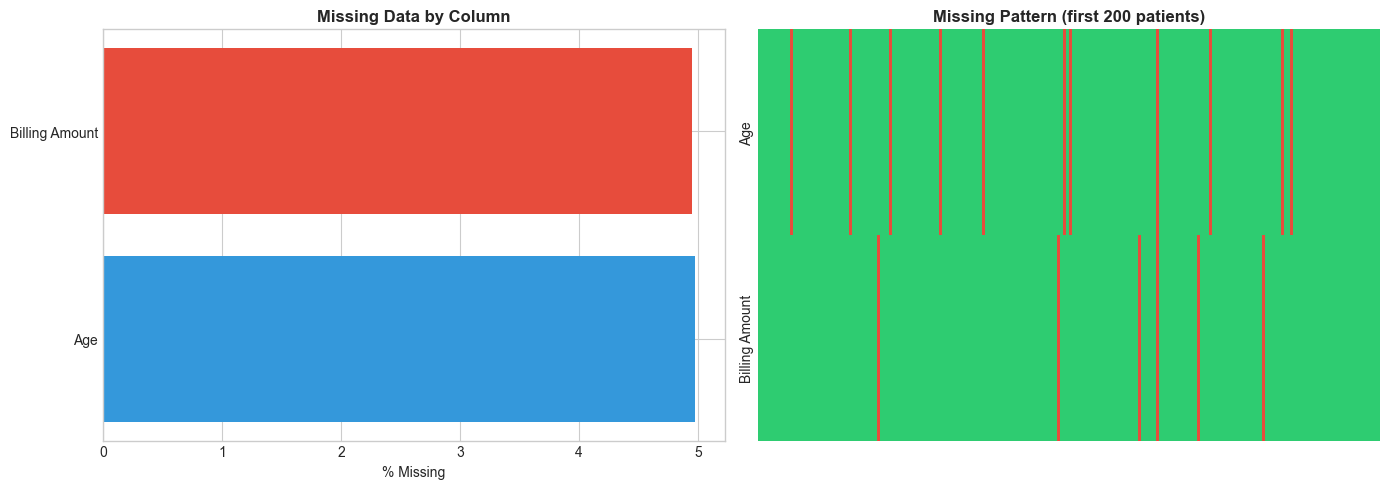

In [4]:
# Our dataset has no missing values, so we'll introduce controlled missingness for demonstration

df_missing = df.copy()

# MCAR: Random 5% of ages
np.random.seed(42)
mcar_mask = np.random.rand(len(df_missing)) < 0.05
df_missing.loc[mcar_mask, 'Age'] = np.nan

# MAR: Patients over 65 have 12% missing billing (Medicare incomplete records)
mar_mask = (df['Age'] > 65) & (np.random.rand(len(df)) < 0.12)
df_missing.loc[mar_mask, 'Billing Amount'] = np.nan

# MNAR: Highest bills (top 5%) more likely missing (billing disputes)
billing_95 = df['Billing Amount'].quantile(0.95)
mnar_mask = (df['Billing Amount'] > billing_95) & (np.random.rand(len(df)) < 0.30)
df_missing.loc[mnar_mask, 'Billing Amount'] = np.nan

print("MISSING DATA INTRODUCED")
print("="*70)
print(f"Age (MCAR):           {df_missing['Age'].isnull().sum():5d} ({df_missing['Age'].isnull().mean()*100:.1f}%)")
print(f"Billing Amount (MAR): {df_missing['Billing Amount'].isnull().sum():5d}")
print(f"  Age>65:  {df_missing[df['Age']>65]['Billing Amount'].isnull().mean()*100:.1f}% missing")
print(f"  Age≤65:  {df_missing[df['Age']<=65]['Billing Amount'].isnull().mean()*100:.1f}% missing")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_summary = pd.DataFrame({
    'Column': ['Age', 'Billing Amount'],
    'Pct': [df_missing['Age'].isnull().mean()*100, df_missing['Billing Amount'].isnull().mean()*100]
})

axes[0].barh(missing_summary['Column'], missing_summary['Pct'], color=['#3498db', '#e74c3c'])
axes[0].set_xlabel('% Missing')
axes[0].set_title('Missing Data by Column', fontweight='bold')

sample = df_missing[['Age', 'Billing Amount']].head(200)
sns.heatmap(sample.isnull().T, cmap=['#2ecc71', '#e74c3c'], cbar=False, yticklabels=True, xticklabels=False, ax=axes[1])
axes[1].set_title('Missing Pattern (first 200 patients)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 3 — Imputation Strategies

### Strategy 1: Deletion

**Listwise deletion** = Remove rows with any missing values  
**Columnwise deletion** = Remove columns with excessive missingness

#### When to Use Deletion

- Missing data < 5% of dataset
- Missingness confirmed as MCAR (via Little's test)
- Large enough sample that losing rows won't hurt power
- Missing values in non-critical features

#### The 50% Rule for Columns

**Rule**: If a column is missing > 50% of values, drop the entire column.

**Why This Rule Exists**:
1. **Too much artificial data**: Imputing >50% means more than half your values are fabricated
2. **Inconsistent collection**: Heavy missingness usually means the feature wasn't systematically collected
3. **Poor model performance**: Models trained on heavily imputed features perform poorly on real data
4. **Better without than fake**: You're better off excluding the feature entirely than training on mostly-synthetic values

**Healthcare Example**: If "MRI Results" is 80% missing, it probably wasn't standard protocol. Drop the column rather than fabricate 80% of values.

#### Pros:
- Simple and fast
- No assumptions about missing values
- No artificial patterns introduced

#### Cons:
- Loses information (smaller sample)
- Reduces statistical power
- Can introduce bias if not MCAR
- May remove rare but important cases

---

### Strategy 2: Mean/Median Imputation

**Method**: Replace missing numerical values with the column's mean or median.

#### Mean vs Median — Which to Use?

**Use MEAN when**:
- Data is approximately normally distributed
- No extreme outliers present
- You want to preserve exact average

**Use MEDIAN when**:
- Data is skewed (right or left tail)
- Outliers are present
- Healthcare data (almost always has outliers)

**Why Median in Healthcare**: Patient populations have long-tailed distributions. A few patients with extreme ages, costs, or lab values. Median is robust to these outliers.

#### When to Use:
- 5-30% missing data
- Feature is numeric
- Features are largely independent (not strongly correlated)
- Quick baseline before sophisticated methods

#### Pros:
- Very fast (O(n) complexity)
- Preserves sample size
- Easy to explain to stakeholders

#### Cons:
- **Underestimates variance**: All imputed values identical → artificial certainty
- **Distorts distribution**: Creates spike at mean/median
- **Ignores relationships**: Doesn't use information from other features
- **Breaks correlations**: If Age and Billing correlate, median breaks this

---

### Strategy 3: Mode Imputation (Categorical)

**Method**: Replace missing categorical values with the most frequent category.

**Example**: Insurance has [Medicare: 40%, Medicaid: 30%, Private: 25%, None: 5%]  
Missing values → filled with "Medicare" (the mode)

#### When to Use:
- Categorical features with clear dominant category
- < 15% missing data
- Mode truly represents "typical" case

#### Pros:
- Simple and fast
- Only option for categorical with simple imputers
- Preserves sample size

#### Cons:
- **Amplifies dominant category**: Medicare 40% → becomes 45%
- **May not be representative**: Mode might be arbitrary if distribution is flat
- **Ignores patterns**: Doesn't consider that older patients more likely have Medicare

#### Healthcare Consideration:
Be careful with sensitive categories (ethnicity, insurance). Mode imputation can amplify existing biases.

---

### Strategy 4: KNN Imputation

**Method**: For each missing value, find K most similar patients (using other features) and impute with their average.

#### How KNN Works:

1. **Distance Calculation**: For patient with missing Age:
   - Calculate distance to all other patients using complete features (Gender, Blood Type, Billing, etc.)
   - Usually Euclidean distance after standardization

2. **Find Neighbors**: Select K=5 nearest patients with non-missing Age

3. **Impute**: 
   - Numeric: Take mean of neighbors' values
   - Categorical: Take mode of neighbors' values

4. **Weighting**: Can use distance-weighted average (closer neighbors count more)

#### Why KNN Preserves Relationships

**Example**: If older patients have higher billing:
- Patient: Age=missing, Billing=$45,000
- KNN finds 5 similar patients with similar billing
- These neighbors are likely older (Age and Billing correlate)
- Imputed age reflects this relationship

**Contrast with Median**: Median gives same age to everyone regardless of billing.

#### When KNN is Preferred Over Median

1. **Features are correlated**: Age ↔ Billing, BMI ↔ Medications
2. **Missing rate is moderate**: 5-30% (needs complete cases for neighbors)
3. **Accuracy > Speed**: KNN is 10-100x slower but more accurate
4. **Mixed data types**: KNN handles numeric + categorical together

#### Parameters to Tune:
- **n_neighbors (K)**: Usually 3-10. Higher K = smoother
- **weights**: 'uniform' (all equal) vs 'distance' (closer weighted more)
- **metric**: 'euclidean', 'manhattan', 'minkowski'

#### Pros:
- **Preserves relationships** between features
- **Maintains distribution** (no artificial spikes)
- **Realistic values** (actual patient-like combinations)
- Works with mixed types

#### Cons:
- **Computationally expensive**: O(n²) for distances
- **Requires scaling**: Age (0-100) vs Billing (0-100K) need standardization
- **Requires tuning K**: Too small = noise sensitive, too large = oversmoothing
- **Needs complete cases**: If multiple features missing, hard to find neighbors

---

### Strategy 5: Forward/Backward Fill

**Method**: For time-series, use previous (forward) or next (backward) observation.

**When to Use**:
- Time-series or longitudinal data
- Values change slowly over time
- Data is ordered chronologically

**Healthcare Example**: Vital signs in ICU — fill missing BP with last recorded.

#### Pros:
- Maintains temporal trends

#### Cons:
- Propagates outdated values
- Only works for sequential data

---

### Strategy 6: Flagging Missingness

**Method**: Create binary indicator `feature_was_missing` and impute original with placeholder.

**When to Use**:
- MNAR suspected
- Missingness is clinically significant
- Want model to learn from absence pattern

**Healthcare Example**: Patient refused HIV test → refusal itself predicts risk behaviors.

#### Pros:
- Captures informative missingness
- Model learns diagnostic signal

#### Cons:
- Adds dimensionality
- May introduce multicollinearity


In [5]:
# Strategy 1: Deletion

cols_to_drop = df_missing.isnull().mean()[df_missing.isnull().mean() > 0.5].index.tolist()

print("STRATEGY 1: DELETION")
print("="*70)
print(f"Columns >50% missing: {cols_to_drop if cols_to_drop else 'None'}")

df_deleted = df_missing.dropna(subset=['Age'])
print(f"\nRows before: {len(df_missing):,}")
print(f"Rows after:  {len(df_deleted):,}")
print(f"Rows lost:   {len(df_missing)-len(df_deleted):,} ({(len(df_missing)-len(df_deleted))/len(df_missing)*100:.2f}%)")
print(f"\n✅ Acceptable for MCAR <5%")

STRATEGY 1: DELETION
Columns >50% missing: None

Rows before: 55,500
Rows after:  52,738
Rows lost:   2,762 (4.98%)

✅ Acceptable for MCAR <5%


STRATEGY 2: MEDIAN IMPUTATION
Median age: 52.0 years
Values imputed: 2762


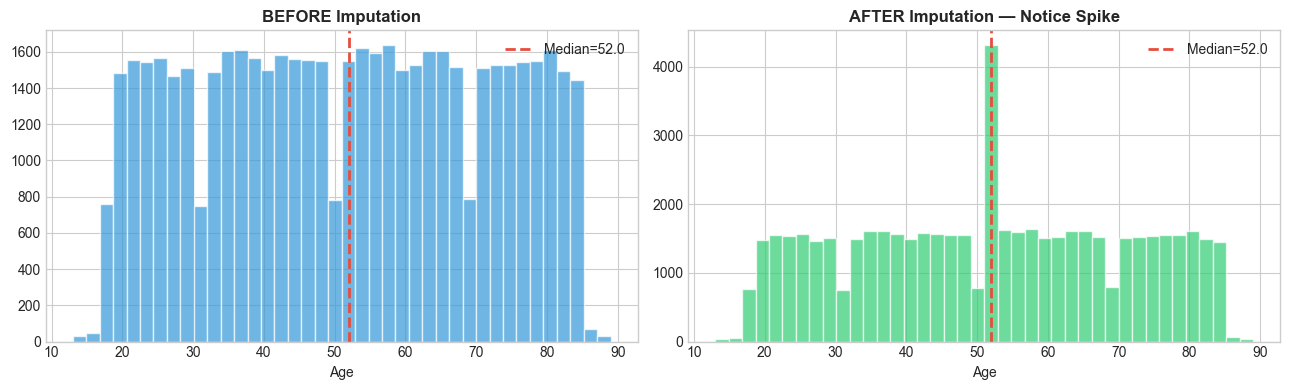


⚠️  Problem: Spike at median = 52.0
   Std Dev: Before=19.59, After=19.10
   Variance underestimated!


In [6]:
# Strategy 2: Median Imputation

df_median = df_missing.copy()
median_imputer = SimpleImputer(strategy='median')
df_median['Age'] = median_imputer.fit_transform(df_median[['Age']])

median_val = median_imputer.statistics_[0]

print("STRATEGY 2: MEDIAN IMPUTATION")
print("="*70)
print(f"Median age: {median_val:.1f} years")
print(f"Values imputed: {mcar_mask.sum()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(df_missing['Age'].dropna(), bins=40, color='#3498db', alpha=0.7, edgecolor='white')
ax1.axvline(median_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median={median_val:.1f}')
ax1.set_title('BEFORE Imputation', fontweight='bold')
ax1.set_xlabel('Age')
ax1.legend()

ax2.hist(df_median['Age'], bins=40, color='#2ecc71', alpha=0.7, edgecolor='white')
ax2.axvline(median_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median={median_val:.1f}')
ax2.set_title('AFTER Imputation — Notice Spike', fontweight='bold')
ax2.set_xlabel('Age')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n⚠️  Problem: Spike at median = {median_val:.1f}")
print(f"   Std Dev: Before={df_missing['Age'].std():.2f}, After={df_median['Age'].std():.2f}")
print(f"   Variance underestimated!")

STRATEGY 4: KNN IMPUTATION
Features used: ['Age', 'Billing Amount', 'Room Number']
Missing before:
Age               2762
Billing Amount    2749
Room Number          0
dtype: int64

Missing after:
Age               0
Billing Amount    0
Room Number       0
dtype: int64


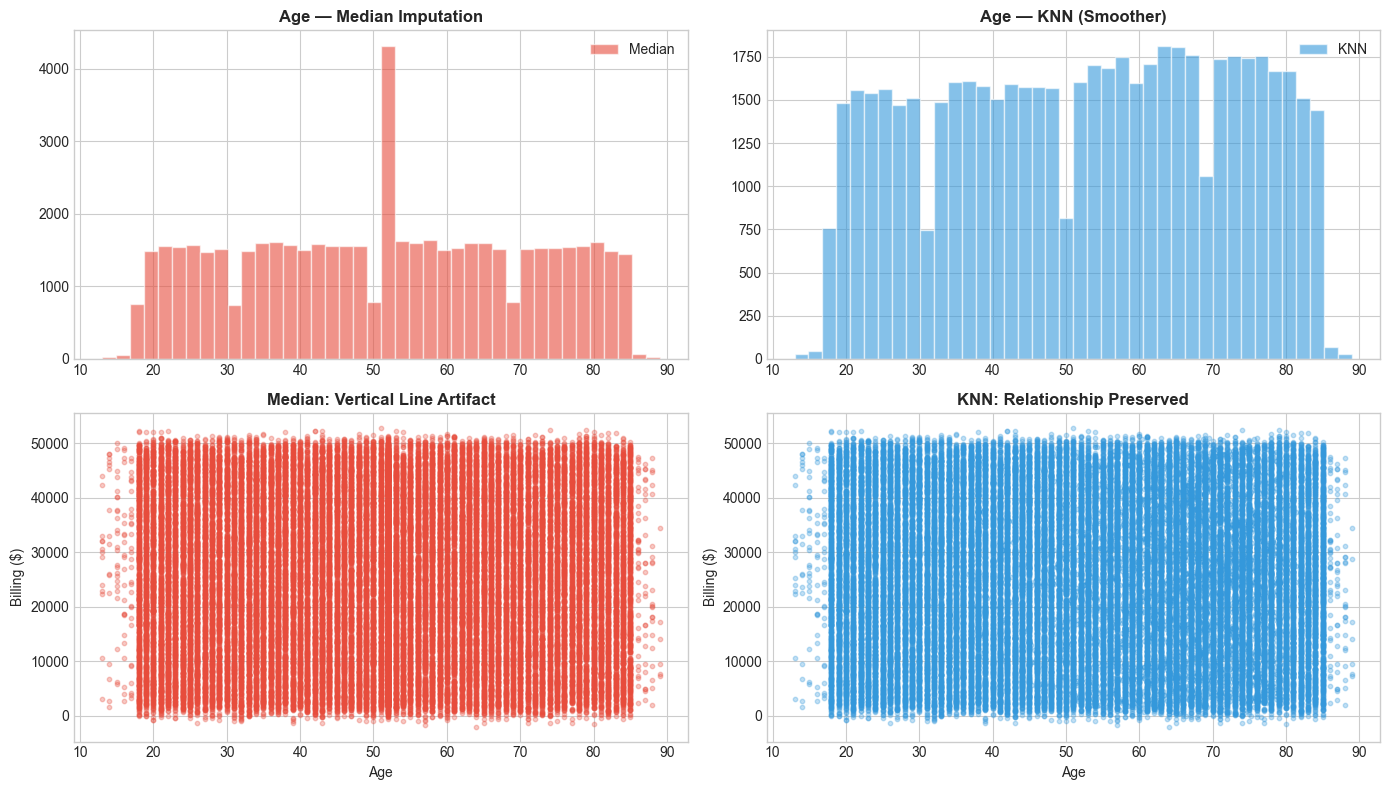


💡 Key Insight:
   KNN preserves Age-Billing correlation
   Median breaks correlation (vertical line)
   Trade-off: KNN slower but more realistic


In [7]:
# Strategy 4: KNN Imputation

knn_features = ['Age', 'Billing Amount', 'Room Number']
df_knn_subset = df_missing[knn_features].copy()

print("STRATEGY 4: KNN IMPUTATION")
print("="*70)
print(f"Features used: {knn_features}")
print(f"Missing before:\n{df_knn_subset.isnull().sum()}")

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_knn_filled = pd.DataFrame(knn_imputer.fit_transform(df_knn_subset), columns=knn_features)

print(f"\nMissing after:\n{df_knn_filled.isnull().sum()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].hist(df_median['Age'], bins=40, alpha=0.6, color='#e74c3c', label='Median', edgecolor='white')
axes[0,0].set_title('Age — Median Imputation', fontweight='bold')
axes[0,0].legend()

axes[0,1].hist(df_knn_filled['Age'], bins=40, alpha=0.6, color='#3498db', label='KNN', edgecolor='white')
axes[0,1].set_title('Age — KNN (Smoother)', fontweight='bold')
axes[0,1].legend()

axes[1,0].scatter(df_median['Age'], df_median['Billing Amount'], alpha=0.3, s=10, color='#e74c3c')
axes[1,0].set_title('Median: Vertical Line Artifact', fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Billing ($)')

axes[1,1].scatter(df_knn_filled['Age'], df_knn_filled['Billing Amount'], alpha=0.3, s=10, color='#3498db')
axes[1,1].set_title('KNN: Relationship Preserved', fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Billing ($)')

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight:")
print(f"   KNN preserves Age-Billing correlation")
print(f"   Median breaks correlation (vertical line)")
print(f"   Trade-off: KNN slower but more realistic")

In [8]:
# Strategy 6: Flagging Missingness

df_flagged = df_missing.copy()

# Create flags
df_flagged['age_was_missing'] = df_missing['Age'].isnull().astype(int)
df_flagged['billing_was_missing'] = df_missing['Billing Amount'].isnull().astype(int)

# Then impute
df_flagged['Age'].fillna(df_flagged['Age'].median(), inplace=True)
df_flagged['Billing Amount'].fillna(df_flagged['Billing Amount'].median(), inplace=True)

print("STRATEGY 6: FLAGGING MISSINGNESS")
print("="*70)
print(f"New features created:")
print(f"  age_was_missing:     {df_flagged['age_was_missing'].sum()} patients")
print(f"  billing_was_missing: {df_flagged['billing_was_missing'].sum()} patients")

print(f"\n💡 Model can now learn FROM the missingness pattern")
print(f"   Useful when absence means something (MNAR)")

STRATEGY 6: FLAGGING MISSINGNESS
New features created:
  age_was_missing:     2762 patients
  billing_was_missing: 2749 patients

💡 Model can now learn FROM the missingness pattern
   Useful when absence means something (MNAR)


---
## Section 4 — Outlier Detection

### What Outliers Represent in Healthcare

**Outliers** are data points that deviate significantly from the pattern. In clinical data, they can be:

1. **Data Entry Errors**: Age=999, BP=0, Height=0.3m
2. **Measurement Errors**: Equipment malfunction, wrong units (kg ↔ lbs)
3. **Rare But Valid Cases**: Patient with genuine extreme vital signs
4. **Processing Errors**: Data corruption, encoding mistakes

**Key Principle**: Don't automatically remove outliers — understand them first. In healthcare, extreme values might represent:
- Rare diseases worth studying
- Critical cases requiring urgent attention
- Data quality issues that need fixing

---

### Detection Method 1: Z-Score

**Formula**: $z = \frac{x - \mu}{\sigma}$

**Rule**: Flag values where $|z| > 3$ (beyond 3 standard deviations)

**What This Means**: In a normal distribution, 99.7% of data falls within ±3σ. Values beyond this are the most extreme 0.3%.

**Assumption**: Data is approximately normally distributed

**When to Use**: Gaussian features without heavy tails

#### Pros:
- Simple to calculate
- Interpretable (number of standard deviations from mean)
- Works well for symmetric distributions

#### Cons:
- Assumes normality (most healthcare data is skewed)
- Mean and SD are themselves affected by outliers
- Not robust for heavy-tailed distributions

---

### Detection Method 2: IQR (Interquartile Range)

**Formula**:
- $IQR = Q_3 - Q_1$ (75th percentile minus 25th percentile)
- Lower bound = $Q_1 - 1.5 \times IQR$
- Upper bound = $Q_3 + 1.5 \times IQR$

**What This Means**: The "box" in a boxplot covers Q1 to Q3 (middle 50%). Whiskers extend 1.5×IQR. Points beyond whiskers are outliers.

**Why 1.5?**: This is Tukey's rule. It's a balance — not too sensitive, not too lenient. For normally distributed data, this flags ~0.7% as outliers.

**Assumption**: None! This is a non-parametric method.

**When to Use**: Skewed data, heavy tails, when you don't want to assume normality

#### Pros:
- **Robust to skew**: Works on any distribution
- **Not affected by extreme values**: Uses quartiles, not mean
- **Visual**: This is what boxplots show
- **Preferred for healthcare data**: Most clinical variables are skewed

#### Cons:
- May flag too many points in very heavy-tailed distributions
- 1.5 factor is somewhat arbitrary (can adjust to 2.0 or 3.0 for more lenient)

---

### Detection Method 3: Isolation Forest

**Method**: Machine learning algorithm that isolates anomalies using random decision trees.

**How It Works**: 
1. Build random decision trees by randomly selecting features and split points
2. Anomalies are **easier to isolate** (require fewer splits to separate from others)
3. Normal points are **harder to isolate** (require many splits)
4. Anomaly score = average tree depth (lower = more anomalous)

**Intuition**: Think of trying to describe a person in a crowd:
- Unusual person: "The 7-foot-tall person with purple hair" (2 descriptors)
- Normal person: "The person with brown hair, 5'8", wearing jeans, 35 years old..." (many descriptors)

**When to Use**:
- High-dimensional data (many features)
- Multivariate outliers (normal in each dimension but weird combination)
- No assumptions about distribution

#### Parameters:
- **contamination**: Expected percentage of outliers (default 0.1 = 10%)
- **n_estimators**: Number of trees (default 100)

#### Pros:
- Works in high dimensions
- No distribution assumptions
- Detects **multivariate outliers** (combinations that are unusual even if each value alone is normal)
- Fast (linear in number of samples)

#### Cons:
- Black box (less interpretable than Z-score or IQR)
- Requires tuning contamination parameter
- May flag novel patterns that are actually interesting

---

### Detection Method 4: Domain Knowledge (Most Important!)

**Method**: Define physiologically plausible ranges based on medical knowledge.

**Healthcare-Specific Ranges**:
- **Age**: 0-120 years (oldest verified human: 122)
- **Heart Rate**: 30-200 bpm (bradycardia to extreme tachycardia)
- **Systolic BP**: 70-250 mmHg (hypotension to hypertensive crisis)
- **Body Temp**: 95-106°F (hypothermia to severe fever)
- **Oxygen Saturation**: 70-100% (severe hypoxia to normal)
- **BMI**: 10-70 (severe underweight to severe obesity)

**Values outside these ranges are definitively erroneous.**

**Why This Is Best**: 
- Catches data entry errors (Age=999, BP=0)
- Based on medical reality, not statistics
- Easy to explain to clinical stakeholders
- Prevents training models on impossible values

**How to Get Ranges**: Consult with domain experts (physicians, nurses) for each variable.

---

### Detection Strategy Comparison

| Method | Best For | Assumption | Pros | Cons |
|--------|----------|------------|------|------|
| **Z-Score** | Symmetric data | Normal distribution | Simple, interpretable | Assumes normality |
| **IQR** | Skewed data | None | Robust, visual | May be too sensitive |
| **Isolation Forest** | High-dimensional | None | Finds combinations | Black box |
| **Domain Rules** | All healthcare data | Medical knowledge | Catches errors | Need expert input |

**Recommended Approach**: Use domain rules first, then IQR for remaining univariate outliers, then Isolation Forest for multivariate patterns.


OUTLIER DETECTION
Numerical features: ['Age', 'Billing Amount', 'Room Number']



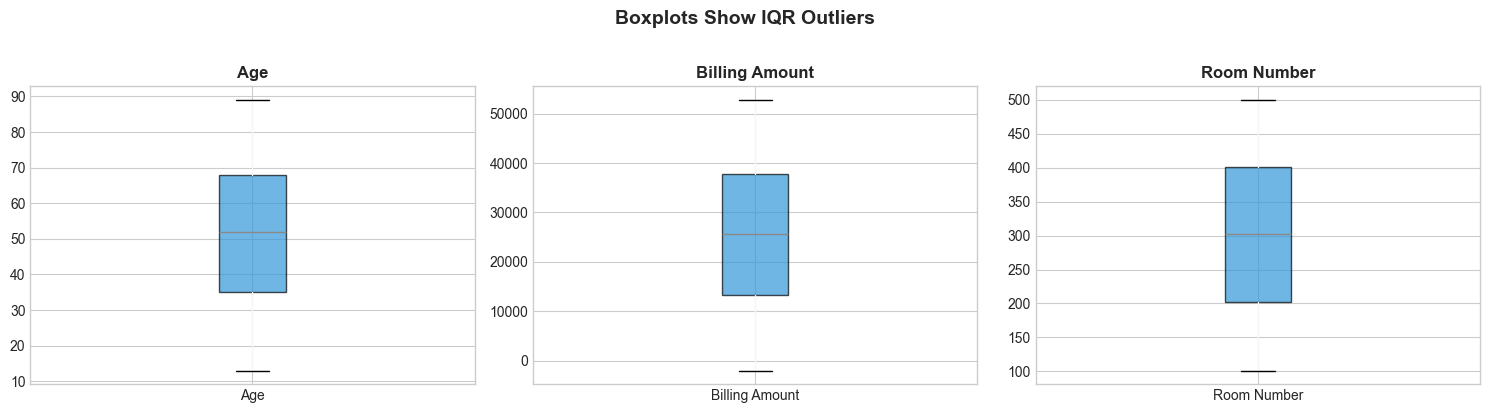

📊 Boxplot: Box=Q1 to Q3, Whiskers=1.5×IQR, Dots=Outliers


In [9]:
# Detect outliers using multiple methods

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("OUTLIER DETECTION")
print("="*70)
print(f"Numerical features: {numerical_cols}\n")

# Visualize with boxplots
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 4))
if len(numerical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numerical_cols):
    df.boxplot(column=col, ax=ax, patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.7))
    ax.set_title(col, fontweight='bold')

plt.suptitle('Boxplots Show IQR Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📊 Boxplot: Box=Q1 to Q3, Whiskers=1.5×IQR, Dots=Outliers")

In [10]:
# Method 1: Z-Score Detection

print("\nZ-SCORE DETECTION (|z| > 3)")
print("="*70)

for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    outliers = (z_scores > 3).sum()
    if outliers > 0:
        print(f"{col:20s}: {outliers:5d} outliers ({outliers/len(df)*100:.2f}%)")
        print(f"  Range: [{df[col].min():.2f}, {df[col].max():.2f}]")


Z-SCORE DETECTION (|z| > 3)


In [11]:
# Method 2: IQR Detection

def detect_outliers_iqr(series, factor=1.5):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return (series < lower) | (series > upper), lower, upper

print("\nIQR DETECTION (1.5 × IQR)")
print("="*70)

for col in numerical_cols:
    outlier_mask, lower, upper = detect_outliers_iqr(df[col])
    n_outliers = outlier_mask.sum()
    if n_outliers > 0:
        print(f"{col:20s}: {n_outliers:5d} outliers ({n_outliers/len(df)*100:.2f}%)")
        print(f"  Acceptable range: [{lower:.2f}, {upper:.2f}]")


IQR DETECTION (1.5 × IQR)



ISOLATION FOREST
Contamination: 0.05 (expecting 5% outliers)
Detected: 2775 (5.00%)


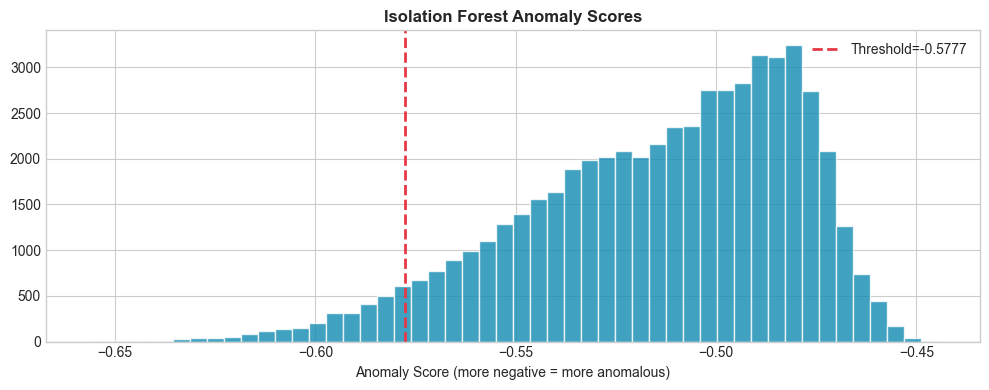


💡 Isolation Forest finds multivariate outliers
   Points normal in each dimension but unusual in combination


In [12]:
# Method 3: Isolation Forest

numeric_subset = df[numerical_cols].dropna()

iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
outlier_labels = iso_forest.fit_predict(numeric_subset)
outlier_scores = iso_forest.score_samples(numeric_subset)

n_outliers = (outlier_labels == -1).sum()

print("\nISOLATION FOREST")
print("="*70)
print(f"Contamination: 0.05 (expecting 5% outliers)")
print(f"Detected: {n_outliers} ({n_outliers/len(numeric_subset)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(outlier_scores, bins=50, color='#118AB2', edgecolor='white', alpha=0.8)
ax.axvline(iso_forest.offset_, color='#E63946', linestyle='--', linewidth=2, label=f'Threshold={iso_forest.offset_:.4f}')
ax.set_xlabel('Anomaly Score (more negative = more anomalous)')
ax.set_title('Isolation Forest Anomaly Scores', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n💡 Isolation Forest finds multivariate outliers")
print(f"   Points normal in each dimension but unusual in combination")

---
## Section 5 — Outlier Treatment

### The Central Question: Delete or Transform?

Once we've detected outliers, we must decide how to handle them.

---

### Treatment 1: Deletion

**Method**: Remove rows containing outliers.

**When to Use**:
- Value is definitively a data entry error (Age=999, BP=0)
- Outliers represent <1% of data
- You have large enough sample that losing rows is acceptable

**Healthcare Consideration**: **Be very careful with deletion in clinical data.** Deleting a patient record because their BMI is 45 (obese but valid) throws away exactly the patients we want to study.

**Why Deletion is Dangerous**:
- Removes rare but important cases
- Can introduce bias (e.g., removing all severe cases)
- Reduces sample size and statistical power
- May remove precisely the patients most at risk

**Better approach**: Understand WHY it's an outlier before deleting.

---

### Treatment 2: Capping (Winsorizing)

**Method**: Clip values to acceptable bounds rather than deleting the entire row.

**Two Approaches**:

1. **Domain-Driven Capping**: Based on medical knowledge
   - Age: clip to [18, 100]
   - BMI: clip to [10, 70]
   - Systolic BP: clip to [70, 250]

2. **Data-Driven Capping** (Winsorizing): Based on percentiles
   - Clip to 1st and 99th percentiles
   - Or 5th and 95th for more aggressive capping

**Why Capping is Preferred in Healthcare**:
- **Preserves the patient record**: Keeps the row in your dataset
- **Retains information**: Other features remain intact
- **Clinically sensible**: BP=300 is likely BP=200 with data error
- **Less bias**: Doesn't systematically remove severe cases

**Example**: Patient with BP=300 (likely measurement error)
- Deletion: Lose entire patient record
- Capping to 250: Keep patient, fix obvious error

**When to Cap**:
- Values are physiologically impossible
- Clear measurement errors
- Want to keep the patient in the analysis
- Using linear models or neural networks (sensitive to outliers)

**When NOT to Cap**:
- Using tree-based models (robust to outliers anyway)
- Studying extreme cases (e.g., research on severe obesity)
- Values are rare but legitimate

---

### Treatment 3: Transformation

**Method**: Apply mathematical transformation to reduce skew and compress outliers.

**Common Transformations**:

1. **Log Transform**: $x' = \log(x + 1)$
   - Use for: Right-skewed data (long tail to the right)
   - Examples: Income, billing amounts, lab values
   - Effect: Compresses large values, spreads small values

2. **Square Root**: $x' = \sqrt{x}$
   - Use for: Moderate right skew (less aggressive than log)
   - Examples: Count data, rates
   - Effect: Gentle compression of large values

3. **Cube Root**: $x' = x^{1/3}$
   - Use for: Can handle negative values (unlike log and sqrt)
   - Effect: Similar to sqrt but works on negative numbers

**When to Transform**:
- Data is heavily skewed
- You want to normalize distribution for linear models
- Many features have similar scale after transformation

**Pros**:
- Reduces impact of extreme values
- Can make distribution more normal
- Helps linear models perform better

**Cons**:
- **Loses interpretability**: What does $\log(glucose) = 4.8$ mean?
- **Not reversible** without extra work
- **May not help** tree-based models (already robust)

**Healthcare Consideration**: For clinical stakeholders, interpretability matters. Prefer capping over transformation when explaining to physicians.

---

### Treatment 4: Robust Scaling

**Method**: Use median and IQR instead of mean and SD for scaling.

**RobustScaler Formula**: $x' = \frac{x - median(x)}{IQR(x)}$

**When to Use**:
- You need to scale features but have outliers
- Using linear models or neural networks
- Don't want outliers to dominate the scaling

**Comparison**:
- StandardScaler: Uses mean and SD (affected by outliers)
- RobustScaler: Uses median and IQR (resistant to outliers)

**Effect**: Outliers still present but don't distort the scaling of normal values.

---

### Treatment 5: Flagging

**Method**: Create binary feature `is_outlier` and keep original value.

**When to Use**:
- Extreme values might be clinically significant
- Want model to learn different patterns for outliers vs normal
- Research context where extreme cases matter

**Example**: Very high billing amounts might predict different outcomes. Flag them instead of capping.

---

### Decision Framework

```
IF value is physiologically impossible:
    → Use domain-driven capping OR delete

IF value is rare but possibly valid:
    → Keep unchanged (especially for tree models)
    → OR flag as binary feature
    → OR use robust scaling

IF using linear models/neural nets:
    → Cap to reasonable bounds
    → OR transform (log/sqrt)
    → OR use robust scaling

IF using tree-based models:
    → Often no treatment needed
    → Trees are naturally robust to outliers
```


In [13]:
# Treatment 1: Domain-Driven Capping

df_clean = df.copy()

CLINICAL_BOUNDS = {
    'Age': (18, 100),
    'Billing Amount': (0, 200000),  # Reasonable max for US hospital stay
    'Room Number': (100, 500)  # Typical hospital room range
}

print("OUTLIER TREATMENT: DOMAIN-DRIVEN CAPPING")
print("="*70)
print(f"{'Feature':<20} {'Min Before':<12} {'Max Before':<12} {'Lower':<10} {'Upper':<10} {'Min After':<12} {'Max After':<12}")
print("-"*90)

for col, (lower, upper) in CLINICAL_BOUNDS.items():
    if col in df_clean.columns:
        min_before = df_clean[col].min()
        max_before = df_clean[col].max()
        
        df_clean[col] = df_clean[col].clip(lower, upper)
        
        min_after = df_clean[col].min()
        max_after = df_clean[col].max()
        
        print(f"{col:<20} {min_before:<12.2f} {max_before:<12.2f} {lower:<10} {upper:<10} {min_after:<12.2f} {max_after:<12.2f}")

print(f"\n✅ Values capped to clinically plausible ranges")
print(f"   Preserves patient records while fixing measurement errors")

OUTLIER TREATMENT: DOMAIN-DRIVEN CAPPING
Feature              Min Before   Max Before   Lower      Upper      Min After    Max After   
------------------------------------------------------------------------------------------
Age                  13.00        89.00        18         100        18.00        89.00       
Billing Amount       -2008.49     52764.28     0          200000     0.00         52764.28    
Room Number          101.00       500.00       100        500        101.00       500.00      

✅ Values capped to clinically plausible ranges
   Preserves patient records while fixing measurement errors


In [14]:
# Treatment 2: Percentile-Based Winsorizing

df_winsorized = df.copy()

print("\nWINSORIZING (1st and 99th percentiles)")
print("="*70)

for col in numerical_cols:
    p01 = df_winsorized[col].quantile(0.01)
    p99 = df_winsorized[col].quantile(0.99)
    
    df_winsorized[col] = df_winsorized[col].clip(p01, p99)
    
    print(f"{col:<20} capped at [{p01:.2f}, {p99:.2f}]")

print(f"\n💡 Winsorizing:")
print(f"   Data-driven (adapts to your distribution)")
print(f"   Domain capping: Knowledge-driven (enforces medical validity)")
print(f"   ➜ Prefer domain capping when bounds are known")


WINSORIZING (1st and 99th percentiles)
Age                  capped at [18.00, 85.00]
Billing Amount       capped at [1225.79, 49848.12]
Room Number          capped at [104.00, 496.00]

💡 Winsorizing:
   Data-driven (adapts to your distribution)
   Domain capping: Knowledge-driven (enforces medical validity)
   ➜ Prefer domain capping when bounds are known


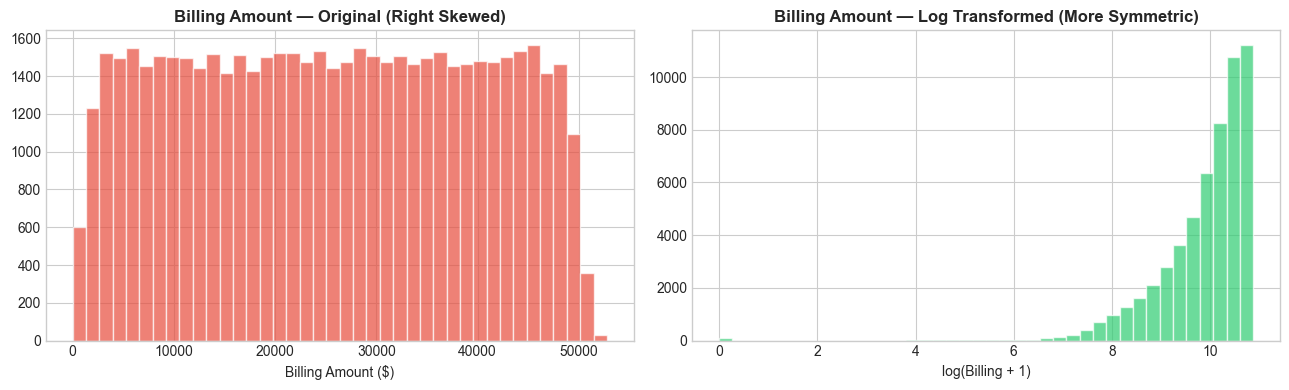


💡 Log Transformation:
   ✓ Reduces right skew
   ✓ Compresses extreme values
   ✗ Loses interpretability (what does log($)=10.5 mean?)
   Best for: Linear models on skewed features


In [15]:
# Treatment 3: Log Transformation

df_transformed = df_clean.copy()

# Billing Amount is right-skewed — try log transform
df_transformed['billing_log'] = np.log1p(df_transformed['Billing Amount'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(df_clean['Billing Amount'], bins=40, color='#e74c3c', alpha=0.7, edgecolor='white')
ax1.set_title('Billing Amount — Original (Right Skewed)', fontweight='bold')
ax1.set_xlabel('Billing Amount ($)')

ax2.hist(df_transformed['billing_log'], bins=40, color='#2ecc71', alpha=0.7, edgecolor='white')
ax2.set_title('Billing Amount — Log Transformed (More Symmetric)', fontweight='bold')
ax2.set_xlabel('log(Billing + 1)')

plt.tight_layout()
plt.show()

print(f"\n💡 Log Transformation:")
print(f"   ✓ Reduces right skew")
print(f"   ✓ Compresses extreme values")
print(f"   ✗ Loses interpretability (what does log($)=10.5 mean?)")
print(f"   Best for: Linear models on skewed features")

---
## Section 6 — Duplicates & String Inconsistencies

### Duplicate Types

1. **Exact Duplicates**: Identical rows across all columns
2. **Key-Based Duplicates**: Same patient ID with different data (multiple admissions or errors)
3. **Fuzzy Duplicates**: Similar but not identical (typos, formatting)
4. **Semantic Duplicates**: Different text, same meaning ("Diabetes Type 2" vs "T2DM")

### String Inconsistencies

Common issues in healthcare data:
- **Inconsistent capitalization**: "Male" vs "male" vs "MALE"
- **Whitespace**: "Blue Cross " vs "Blue Cross"
- **Abbreviations**: "St." vs "Saint", "Dr" vs "Doctor"
- **Misspellings**: "Jhon" vs "John"

### Why This Matters

- Models treat "Male" and "male" as different categories
- Duplicate patients inflate sample size
- String inconsistencies prevent proper grouping


In [16]:
# Check for duplicates

print("DUPLICATE DETECTION")
print("="*70)

# Exact duplicates
n_exact = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact}")

# Key-based (same patient ID)
n_patient_dupes = df['Name'].duplicated().sum()
print(f"Duplicate patient names: {n_patient_dupes}")

if n_exact > 0:
    # Show example
    dupes = df[df.duplicated(keep=False)].sort_values('Name')
    print(f"\nExample duplicates:")
    print(dupes.head())

DUPLICATE DETECTION
Exact duplicate rows: 534
Duplicate patient names: 5508

Example duplicates:
                Name  Age  Gender Blood Type Medical Condition  \
54285  ABIgaIL YOung   41  Female         O+      Hypertension   
42407  ABIgaIL YOung   41  Female         O+      Hypertension   
26025  ALIcia taYLoR   78    Male         O+            Asthma   
53104  ALIcia taYLoR   78    Male         O+            Asthma   
50151      AMy GREEN   79  Female         B+           Obesity   

      Date of Admission         Doctor           Hospital Insurance Provider  \
54285        2022-12-15  Edward Kramer     Moore-Mcdaniel   UnitedHealthcare   
42407        2022-12-15  Edward Kramer     Moore-Mcdaniel   UnitedHealthcare   
26025        2022-09-18    Dawn Burton         Wright LLC              Aetna   
53104        2022-09-18    Dawn Burton         Wright LLC              Aetna   
50151        2021-03-30  Brett Johnson  Taylor-Williamson   UnitedHealthcare   

       Billing Amount  Ro

In [17]:
# Fix string inconsistencies in Name column

# Show the problem
print("STRING INCONSISTENCY PROBLEM")
print("="*70)
print(f"Sample names with mixed casing:")
print(df['Name'].head(10).tolist())

# Standardize
df_clean['Name'] = df_clean['Name'].str.title()  # Proper Case Each Word

print(f"\nAfter standardization:")
print(df_clean['Name'].head(10).tolist())

# Gender standardization
print(f"\nGender BEFORE: {df['Gender'].unique()}")
df_clean['Gender'] = df_clean['Gender'].str.lower().str.strip()
print(f"Gender AFTER:  {df_clean['Gender'].unique()}")

print(f"\n✅ String normalization:")
print(f"   - Consistent capitalization")
print(f"   - Whitespace removed")
print(f"   - Ready for encoding")

STRING INCONSISTENCY PROBLEM
Sample names with mixed casing:
['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH', 'andrEw waTtS', 'adrIENNE bEll', 'EMILY JOHNSOn', 'edwArD EDWaRDs', 'CHrisTInA MARtinez', 'JASmINe aGuIlaR', 'ChRISTopher BerG']

After standardization:
['Bobby Jackson', 'Leslie Terry', 'Danny Smith', 'Andrew Watts', 'Adrienne Bell', 'Emily Johnson', 'Edward Edwards', 'Christina Martinez', 'Jasmine Aguilar', 'Christopher Berg']

Gender BEFORE: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Gender AFTER:  <StringArray>
['male', 'female']
Length: 2, dtype: str

✅ String normalization:
   - Consistent capitalization
   - Whitespace removed
   - Ready for encoding


In [18]:
# Date parsing

print("\nDATE PARSING")
print("="*70)
print(f"Date of Admission dtype BEFORE: {df['Date of Admission'].dtype}")

df_clean['Date of Admission'] = pd.to_datetime(df_clean['Date of Admission'])
df_clean['Discharge Date'] = pd.to_datetime(df_clean['Discharge Date'])

print(f"Date of Admission dtype AFTER:  {df_clean['Date of Admission'].dtype}")

# Calculate length of stay
df_clean['Length of Stay'] = (df_clean['Discharge Date'] - df_clean['Date of Admission']).dt.days

print(f"\nNew feature created: Length of Stay")
print(f"Mean LOS: {df_clean['Length of Stay'].mean():.1f} days")
print(f"Range: {df_clean['Length of Stay'].min()} to {df_clean['Length of Stay'].max()} days")


DATE PARSING
Date of Admission dtype BEFORE: str
Date of Admission dtype AFTER:  datetime64[us]

New feature created: Length of Stay
Mean LOS: 15.5 days
Range: 1 to 30 days


---
# Part 2: Feature Engineering

Now we switch to the **Maternal Health Dataset** to demonstrate feature engineering techniques.


## Section 7 — Load Maternal Health Dataset

In [20]:
# Load Maternal Health Dataset
df_maternal = pd.read_csv('../data/Maternal Health Risk Data Set.csv')

print("="*70)
print("MATERNAL HEALTH RISK DATASET")
print("="*70)
print(f"Shape: {df_maternal.shape[0]:,} rows × {df_maternal.shape[1]} columns")
print(f"\nColumns: {list(df_maternal.columns)}")
print(f"\nTarget variable (RiskLevel):")
print(df_maternal['RiskLevel'].value_counts())
print(f"\nFirst 5 rows:")
df_maternal.head()

MATERNAL HEALTH RISK DATASET
Shape: 1,014 rows × 7 columns

Columns: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']

Target variable (RiskLevel):
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

First 5 rows:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [21]:
# Data overview
print("\nDATA SUMMARY")
print("="*70)
print(df_maternal.describe())
print(f"\nMissing values:\n{df_maternal.isnull().sum()}")
print(f"\nData types:\n{df_maternal.dtypes}")


DATA SUMMARY
               Age   SystolicBP  DiastolicBP           BS     BodyTemp  \
count  1014.000000  1014.000000  1014.000000  1014.000000  1014.000000   
mean     29.871795   113.198225    76.460552     8.725986    98.665089   
std      13.474386    18.403913    13.885796     3.293532     1.371384   
min      10.000000    70.000000    49.000000     6.000000    98.000000   
25%      19.000000   100.000000    65.000000     6.900000    98.000000   
50%      26.000000   120.000000    80.000000     7.500000    98.000000   
75%      39.000000   120.000000    90.000000     8.000000    98.000000   
max      70.000000   160.000000   100.000000    19.000000   103.000000   

         HeartRate  
count  1014.000000  
mean     74.301775  
std       8.088702  
min       7.000000  
25%      70.000000  
50%      76.000000  
75%      80.000000  
max      90.000000  

Missing values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel  

---
## Section 8 — Categorical Encoding

### Understanding Variable Types

Before encoding, we must understand our variable types:

**Nominal Variables** = Categories with NO inherent order
- Examples: Blood Type (A, B, AB, O), Insurance Provider, Hospital Name
- Math: You cannot say A+ > B+ or Aetna > Cigna

**Ordinal Variables** = Categories WITH inherent order
- Examples: Risk Level (low < mid < high), Pain Scale (1-10), Education Level
- Math: "high risk" > "mid risk" > "low risk" makes sense

**Why This Distinction Matters**:
- **Nominal** → Use One-Hot Encoding (preserves "no order" assumption)
- **Ordinal** → Use Label Encoding (preserves order information)
- **Wrong choice** → Model learns false patterns (e.g., thinking Hospital #3 is "between" Hospital #1 and #5)

---

### Encoding Method 1: One-Hot Encoding

**Method**: Create binary column for each category

**Example**: Blood Type with 4 values
- Original: ['A+', 'B+', 'AB+', 'O+']
- Result: 4 columns (or 3 if drop_first=True)

**When to Use**:
- Nominal variables (no order)
- Low cardinality (< 10 categories typically)
- Tree-based models or linear models

**The Curse of Dimensionality**:
- 100 categories → 100 new columns!
- **Problem**: More features than samples leads to overfitting
- **Solution**: Use target encoding or embeddings for high cardinality

**drop_first Parameter**:
- Creates k-1 columns instead of k (removes redundancy)
- Use when: Linear models (prevents multicollinearity)
- Don't use when: Tree models (handles collinearity fine)

#### Pros:
- No ordinal assumption
- Works with any model type
- Interpretable

#### Cons:
- High dimensionality for many categories
- Sparse matrices (mostly zeros)
- Doesn't handle rare categories well

---

### Encoding Method 2: Label Encoding

**Method**: Assign integer to each category (0, 1, 2, ...)

**Example**: Risk Level
- low risk → 0
- mid risk → 1  
- high risk → 2

**CRITICAL: Order Matters!**
- For ordinal data: Assign integers respecting order
- For nominal data: Label encoding creates false order (BAD for linear models)

**When to Use**:
- Ordinal variables only
- OR tree-based models (trees can learn any pattern regardless of encoding)

**Why Trees Handle It**: Trees split on thresholds. Even if encoded randomly, trees will find the right splits. Linear models assume numeric = ordered, so random encoding breaks them.

#### Pros:
- Compact (1 column regardless of cardinality)
- Preserves ordinal information
- Fast

#### Cons:
- Creates false ordering for nominal variables
- Linear models interpret as continuous
- 'A' encoded as 1, 'B' as 2 implies 'B' is "bigger" than 'A"

---

### Encoding Method 3: Target Encoding

**Method**: Replace category with mean of target variable for that category

**Example**: Insurance Provider
- Medicare patients: 25% readmission → encode as 0.25
- Medicaid patients: 35% readmission → encode as 0.35

**Why It's Powerful**: Captures the predictive relationship directly

**Data Leakage Risk**: This is where target encoding gets dangerous.

**Why You Must Fit on Train Only**:

Imagine you're teaching a student for an exam:
- **Wrong way (fitting on all data)**: Give them the answer key, then test them on the same questions
- **Right way (fitting on train only)**: They study from some materials, then test on new unseen questions

**In ML terms**:
1. **Compute encodings on training set only**: Calculate mean target for each category using ONLY training data
2. **Apply to both sets**: Use these train-computed means to encode both train and test
3. **Why this works**: Test set represents "future unseen data" — we can't use future to predict future

**What Happens If You Fit on All Data**:
- Encodings incorporate information from test set
- Model learns patterns that include "answers"
- Performance on test set artificially inflated
- **Production disaster**: New data has different distribution → model fails

**Real Example**:
- Train: Hospital A has 20% readmission (based on 100 patients)
- Test: Hospital A has 40% readmission (based on 25 patients)  
- If you encoded Hospital A as 25% (using all data), you leaked test information into training

**Smoothing**: Add prior to prevent overfitting on rare categories
- Formula: $\frac{n \times target\_mean + m \times global\_mean}{n + m}$
- Where n = category count, m = smoothing parameter

#### Pros:
- Works with high cardinality
- Captures predictive relationship
- Single column output

#### Cons:
- **Risk of target leakage** if not careful
- **Overfitting on rare categories** (smoothing helps)
- Less interpretable

---

### Encoding Method 4: Frequency Encoding

**Method**: Replace category with its frequency in the dataset

**Example**: 
- Hospital A appears 1000 times → encode as 1000
- Hospital B appears 50 times → encode as 50

**When to Use**:
- Frequency itself is predictive
- High cardinality nominal variables
- Want simple encoding without leakage risk

**Healthcare Example**: Frequently used hospitals might be regional referral centers (sicker patients, different outcomes)

#### Pros:
- No target leakage risk
- Handles high cardinality
- Single column output

#### Cons:
- Loses categorical identity
- Frequency may not be predictive
- Ties treated identically

---

### Encoding Method 5: Binary Encoding

**Method**: Convert category to binary, then split into columns

**Example**: 8 categories
- Label encode: 0-7
- Binary: 000, 001, 010, 011, 100, 101, 110, 111
- Result: 3 columns (log2(8) = 3)

**When to Use**: High cardinality when one-hot explodes dimensionality

**Trade-off**: More compact than one-hot, but less interpretable

---

### Summary Table

| Encoding | Best For | Output Columns | Ordinal Assumption | Leakage Risk |
|----------|----------|----------------|-------------------|--------------|
| **One-Hot** | Nominal, low cardinality | k or k-1 | No | None |
| **Label** | Ordinal OR trees | 1 | Yes | None |
| **Target** | High cardinality | 1 | No | High if misused |
| **Frequency** | Frequency is signal | 1 | No | None |
| **Binary** | High cardinality | log2(k) | Yes | None |


In [22]:
# One-Hot Encoding

# RiskLevel is ordinal, but let's demo one-hot first
df_ohe = df_maternal.copy()
df_ohe = pd.get_dummies(df_ohe, columns=['RiskLevel'], drop_first=True)

print("ONE-HOT ENCODING")
print("="*70)
print(f"Original column: RiskLevel")
print(f"New columns: {[c for c in df_ohe.columns if 'RiskLevel' in c]}")
print(f"\nFirst 5 rows:")
print(df_ohe[[c for c in df_ohe.columns if 'RiskLevel' in c]].head())

print(f"\n💡 One-Hot creates k-1 columns (drop_first=True)")
print(f"   Avoids multicollinearity in linear models")

ONE-HOT ENCODING
Original column: RiskLevel
New columns: ['RiskLevel_low risk', 'RiskLevel_mid risk']

First 5 rows:
   RiskLevel_low risk  RiskLevel_mid risk
0               False               False
1               False               False
2               False               False
3               False               False
4                True               False

💡 One-Hot creates k-1 columns (drop_first=True)
   Avoids multicollinearity in linear models


In [23]:
# Label Encoding for Ordinal Variable

# RiskLevel is ordinal: low < mid < high
df_label = df_maternal.copy()

# Manual mapping to preserve order
risk_mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df_label['RiskLevel_encoded'] = df_label['RiskLevel'].map(risk_mapping)

print("LABEL ENCODING (Ordinal)")
print("="*70)
print(f"Mapping: {risk_mapping}")
print(f"\nOriginal vs Encoded:")
print(df_label[['RiskLevel', 'RiskLevel_encoded']].drop_duplicates().sort_values('RiskLevel_encoded'))

print(f"\n✅ Order preserved: low(0) < mid(1) < high(2)")
print(f"   Correct for ordinal variables")
print(f"   Trees and linear models can now learn the ordering")

LABEL ENCODING (Ordinal)
Mapping: {'low risk': 0, 'mid risk': 1, 'high risk': 2}

Original vs Encoded:
   RiskLevel  RiskLevel_encoded
4   low risk                  0
6   mid risk                  1
0  high risk                  2

✅ Order preserved: low(0) < mid(1) < high(2)
   Correct for ordinal variables
   Trees and linear models can now learn the ordering


In [25]:
# Target Encoding (PROPER WAY - Train Only)

from sklearn.model_selection import train_test_split

# Create binary target for demonstration
y = (df_maternal['RiskLevel'] == 'high risk').astype(int)
X = df_maternal.drop('RiskLevel', axis=1)

# Add a categorical feature for demo (use first letter of blood sugar range)
X['BS_category'] = pd.cut(df_maternal['BS'], bins=3, labels=['low', 'medium', 'high'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("TARGET ENCODING (Correct Method)")
print("=" * 70)
print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

# ✅ FIXED SECTION: Merge TRAIN features + target
train_df = X_train.copy()
train_df['target'] = y_train

# Compute encoding on TRAINING data only
bs_target_encoding = train_df.groupby('BS_category')['target'].mean()

print(f"\nEncodings computed from TRAIN data only:")
print(bs_target_encoding)

# Apply to both train and test
X_train['BS_encoded'] = X_train['BS_category'].map(bs_target_encoding)
X_test['BS_encoded'] = X_test['BS_category'].map(bs_target_encoding)

print(f"\n✅ Correct Process:")
print(f"   1. Compute mean target per category on TRAIN")
print(f"   2. Apply same encoding to both TRAIN and TEST")
print(f"   3. Test encoding uses train statistics (no leakage)")

print(f"\n⚠️  WRONG way would be:")
print(f"   Compute encoding on ALL data → leaks test info into training")

TARGET ENCODING (Correct Method)
Train size: 811
Test size:  203

Encodings computed from TRAIN data only:
BS_category
low       0.132399
medium    0.784615
high      0.855769
Name: target, dtype: float64

✅ Correct Process:
   1. Compute mean target per category on TRAIN
   2. Apply same encoding to both TRAIN and TEST
   3. Test encoding uses train statistics (no leakage)

⚠️  WRONG way would be:
   Compute encoding on ALL data → leaks test info into training


---
## Section 9 — Feature Scaling

### Why Scale Features?

Many ML algorithms are sensitive to feature magnitudes:
- **Distance-based**: KNN, SVM, K-Means (distances dominated by large-scale features)
- **Gradient-based**: Neural Networks, Logistic Regression (learning rates affect features differently)

**Example Problem**: Age (0-100) vs Income (0-1,000,000)
- Unscaled: Income dominates distance calculations
- Scaled: Each feature contributes proportionally

**When Scaling Doesn't Matter**: Tree-based models (trees split on thresholds, scale irrelevant)

---

### The Critical Rule: Fit on Training Data Only

**Why This Rule Exists**:

Think of scaling as "learning the typical range" from your data:
- Training set = What your model studies
- Test set = The exam (unseen)

**Wrong Approach** (leakage):
```python
# DON'T DO THIS
scaler.fit(all_data)  # Learns from test set too
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

**Problem**: Scaler "sees" test set statistics (mean, min, max, etc.) → information leakage

**Right Approach**:
```python
# DO THIS
scaler.fit(X_train)  # Learn ONLY from training
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Apply train statistics
```

**Why It Works**:
- Scaler learns from training data (like model does)
- Test set treated as "future unseen data"
- Test may have different range than train (that's ok! It's realistic)

**Real-World Analogy**:
- Train set: Hospital data from 2020-2022
- Test set: Hospital data from 2023
- Wrong: Use 2023 statistics to scale 2020-2022 (time travel!)
- Right: Use 2020-2022 statistics to scale both periods

**What Happens in Production**:
- New patient arrives (never seen before)
- Must scale using training statistics
- If you fit on all data during development, your production scaling is wrong

---

### Scaler 1: StandardScaler

**Formula**: $x' = \frac{x - \mu}{\sigma}$

**Result**: Mean=0, Standard Deviation=1 (z-scores)

**When to Use**:
- Features are approximately normally distributed
- Linear models (Linear Regression, Logistic Regression)
- SVM with RBF kernel
- Neural Networks
- PCA (Principal Component Analysis)

**Assumptions**: No heavy outliers (they affect mean and SD)

#### Pros:
- Most common scaler
- Works well with normally distributed data
- Preserves shape of distribution

#### Cons:
- **Sensitive to outliers** (mean and SD pulled by extremes)
- Output not bounded (can be negative)

---

### Scaler 2: MinMaxScaler

**Formula**: $x' = \frac{x - \min(x)}{\max(x) - \min(x)}$

**Result**: Range [0, 1]

**When to Use**:
- Neural networks with sigmoid/tanh activation
- Algorithms that expect features in [0,1]
- When you need bounded output
- Image data (pixels already in [0,255] → scale to [0,1])

**Assumptions**: No outliers (they affect min/max drastically)

#### Pros:
- **Bounded output** [0, 1]
- Preserves zero values (0 stays 0)
- All features on same scale

#### Cons:
- **VERY sensitive to outliers** (single outlier can squash entire range)
- Doesn't center data around zero

---

### Scaler 3: RobustScaler

**Formula**: $x' = \frac{x - median(x)}{IQR(x)}$

Where IQR = Q3 - Q1 (75th percentile - 25th percentile)

**Result**: Median=0, IQR=1

**When to Use**:
- **Healthcare data** (almost always has outliers)
- Data with outliers that are legitimate (not errors)
- You tried StandardScaler and outliers caused problems

**Why "Robust"**: Uses median (not mean) and IQR (not SD)
- Median: Not affected by extreme values
- IQR: Uses middle 50% of data, ignores tails

**Comparison**:
- StandardScaler: One outlier at 1000 → shifts everyone
- RobustScaler: Outlier at 1000 → ignored, focuses on typical range

#### Pros:
- **Robust to outliers**
- Best for healthcare data
- Still creates comparable scales

#### Cons:
- Less common (some practitioners unfamiliar)
- Doesn't bound output

---

### Visual Comparison

| Scaler | Centers At | Spread Measure | Outlier Sensitive? | Output Range |
|--------|-----------|----------------|-------------------|--------------|
| **Standard** | Mean (μ) | Std Dev (σ) | Yes | Unbounded |
| **MinMax** | N/A | Max-Min | Very Yes | [0, 1] |
| **Robust** | Median | IQR | No | Unbounded |


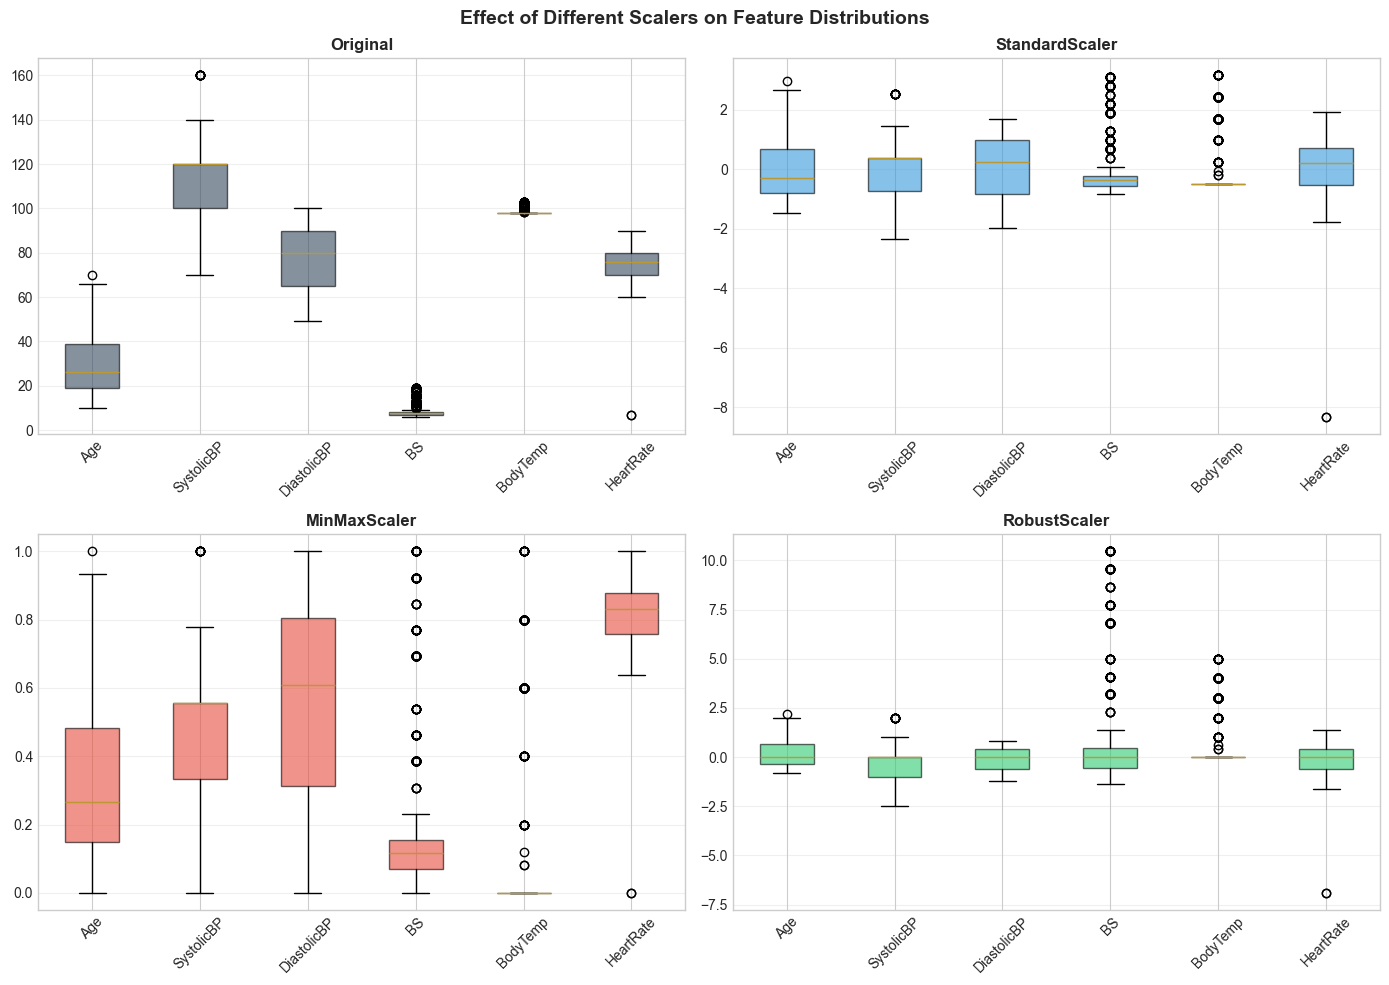

📊 Visual Comparison:
   Standard: Centers at 0, scales by σ
   MinMax: Squashes to [0,1]
   Robust: Centers at median, scales by IQR (most stable)


In [26]:
# Compare scalers visually

features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
sample = df_maternal[features].copy()

scalers = {
    'Original': sample.copy(),
    'StandardScaler': pd.DataFrame(StandardScaler().fit_transform(sample), columns=features),
    'MinMaxScaler': pd.DataFrame(MinMaxScaler().fit_transform(sample), columns=features),
    'RobustScaler': pd.DataFrame(RobustScaler().fit_transform(sample), columns=features)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#34495e', '#3498db', '#e74c3c', '#2ecc71']

for ax, (name, data), color in zip(axes, scalers.items(), colors):
    bp = ax.boxplot([data[f].values for f in features], labels=features, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Effect of Different Scalers on Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Visual Comparison:")
print("   Standard: Centers at 0, scales by σ")
print("   MinMax: Squashes to [0,1]")
print("   Robust: Centers at median, scales by IQR (most stable)")

In [27]:
# Demonstrate proper train-test scaling

# Split data
X = df_maternal[features]
y = df_maternal['RiskLevel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CORRECT: Fit on train, transform both
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=features,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),  # Note: transform only (not fit_transform)
    columns=features,
    index=X_test.index
)

print("PROPER SCALING WORKFLOW")
print("="*70)
print("Train set statistics (what scaler learns):")
print(f"  Age mean: {scaler.mean_[0]:.2f}, std: {np.sqrt(scaler.var_[0]):.2f}")

print(f"\nTrain set after scaling (should be ~0 mean, ~1 std):")
print(f"  Age mean: {X_train_scaled['Age'].mean():.2f}, std: {X_train_scaled['Age'].std():.2f}")

print(f"\nTest set after scaling (may not be exactly 0/1 - that's OK!):")
print(f"  Age mean: {X_test_scaled['Age'].mean():.2f}, std: {X_test_scaled['Age'].std():.2f}")

print(f"\n✅ Correct process:")
print(f"   1. scaler.fit(X_train) - learn from train")
print(f"   2. X_train_scaled = scaler.transform(X_train)")
print(f"   3. X_test_scaled = scaler.transform(X_test) - use train stats")

print(f"\n💡 Test mean ≠ 0 is NORMAL and GOOD")
print(f"   It means test set has different distribution (realistic)")
print(f"   Using test statistics would be cheating (data leakage)")

PROPER SCALING WORKFLOW
Train set statistics (what scaler learns):
  Age mean: 29.79, std: 13.36

Train set after scaling (should be ~0 mean, ~1 std):
  Age mean: -0.00, std: 1.00

Test set after scaling (may not be exactly 0/1 - that's OK!):
  Age mean: 0.03, std: 1.04

✅ Correct process:
   1. scaler.fit(X_train) - learn from train
   2. X_train_scaled = scaler.transform(X_train)
   3. X_test_scaled = scaler.transform(X_test) - use train stats

💡 Test mean ≠ 0 is NORMAL and GOOD
   It means test set has different distribution (realistic)
   Using test statistics would be cheating (data leakage)


---
## Section 9 — Feature Creation

### Why Create New Features?

Raw data rarely contains the optimal feature set for prediction. **Domain knowledge** allows us to create features that:
- Capture important relationships
- Reduce complexity
- Improve model performance
- Encode clinical expertise

**Key Principle**: Domain knowledge > automated feature generation

While automated methods (polynomial features, neural network embeddings) can work, features based on clinical understanding are:
- More interpretable
- More robust across datasets
- More likely to generalize
- Easier to validate

---

### Feature Creation Strategy 1: Date-Derived Features

**Method**: Extract temporal components from datetime columns.

From a single date, we can create:
- **Month**: Seasonal patterns (flu season, summer heat)
- **Day of week**: Weekend vs weekday admission patterns
- **Hour**: Emergency room volume by time
- **Quarter**: Quarterly care patterns
- **Is_weekend**: Binary flag
- **Days_since_epoch**: Numeric representation for trends

**Healthcare example**: Hospital readmissions are higher on Mondays (weekend discharges) and in winter months (flu, pneumonia).

**Why this works**: Temporal patterns affect health outcomes but aren't captured by a single date string.

---

### Feature Creation Strategy 2: Domain-Specific Clinical Features

**Method**: Create features based on medical knowledge.

**Examples**:

**1. BMI Categories** (instead of continuous BMI):
- Underweight: BMI < 18.5
- Normal: 18.5-24.9
- Overweight: 25-29.9
- Obese: ≥ 30

**Why**: Non-linear relationship — risk isn't proportional to BMI. Categories capture clinical thresholds.

**2. Blood Pressure Classification**:
- Normal: SBP < 120 AND DBP < 80
- Elevated: SBP 120-129 AND DBP < 80
- Stage 1 Hypertension: SBP 130-139 OR DBP 80-89
- Stage 2: SBP ≥ 140 OR DBP ≥ 90

**Why**: Clinical guidelines use these categories for treatment decisions.

**3. Pulse Pressure**:
- Formula: Systolic BP - Diastolic BP
- Normal range: 40-60 mmHg
- High pulse pressure → arterial stiffness, cardiovascular risk

**Why**: Captures arterial health better than SBP or DBP alone.

**4. Mean Arterial Pressure (MAP)**:
- Formula: DBP + (SBP - DBP)/3
- Or: (2×DBP + SBP)/3
- Critical threshold: MAP < 60 indicates inadequate organ perfusion

**Why**: Better indicator of perfusion than SBP or DBP individually.

---

### Feature Creation Strategy 3: Interaction Features

**Method**: Multiply or combine features to capture joint effects.

**Examples**:

**1. Age × Chronic Conditions**:
- Young patient + many conditions → unusually high risk
- Old patient + many conditions → expected pattern

**2. BMI × Blood Pressure**:
- Captures metabolic syndrome risk
- Obesity + hypertension → cardiovascular risk

**Healthcare context**: Risk factors often interact. Diabetes + Hypertension is worse than sum of individual risks.

**When to use**:
- Domain knowledge suggests synergy
- Exploratory analysis shows interaction
- Tree models don't need these (learn interactions automatically)
- Linear models benefit greatly

---

### Feature Creation Strategy 4: Ratio Features

**Method**: Create ratios between related measurements.

**Examples in maternal health**:

**1. Blood Sugar to Body Temperature Ratio**:
- Elevated BS + Fever → infection risk
- BS/BodyTemp captures this relationship

**2. Heart Rate to Blood Pressure Ratio**:
- HR/SBP → cardiac output indicator
- Abnormal ratios → hemodynamic instability

**General principle**: When two measurements are physiologically coupled, their ratio often captures the relationship better than raw values.

---

### Feature Creation Strategy 5: Binning (Discretization)

**Method**: Convert continuous variables into categorical bins.

**When to use binning**:
- Non-linear relationships with clear thresholds
- Want model to treat ranges equally
- Reduce impact of outliers
- Encode clinical guidelines

**Example — Age Bins for Maternal Risk**:
- Adolescent: < 20 (high risk)
- Optimal: 20-35 (normal risk)
- Advanced maternal age: > 35 (high risk)

**Why**: Maternal risk is U-shaped with age. Linear relationship doesn't capture this.

**Caution**: Binning loses information. Only use when clinical rationale exists.

---

### Domain Knowledge > Automation

**Automated feature generation** (polynomial features, neural embeddings):
- **Pros**: Finds patterns you might miss
- **Cons**: Creates hundreds of features, hard to interpret, may overfit

**Domain-driven feature creation**:
- **Pros**: Interpretable, robust, clinically valid
- **Cons**: Requires expertise, might miss subtle patterns

**Best practice**: Start with domain features, add automated methods if needed.

**Example**:
- ❌ Bad: Generate all polynomial combinations → 100+ features, many nonsensical
- ✅ Good: Create Pulse Pressure (clinical meaning) → 1 interpretable feature

---


In [28]:
# Feature Creation on Maternal Health Dataset

print("FEATURE CREATION")
print("="*70)

df_features = df_maternal.copy()

# 1. Domain-Specific: Blood Pressure Classification
def classify_bp(row):
    sbp, dbp = row['SystolicBP'], row['DiastolicBP']
    if sbp < 120 and dbp < 80:
        return 'Normal'
    elif 120 <= sbp < 130 and dbp < 80:
        return 'Elevated'
    elif (130 <= sbp < 140) or (80 <= dbp < 90):
        return 'Stage1_HTN'
    else:
        return 'Stage2_HTN'

df_features['BP_Category'] = df_features.apply(classify_bp, axis=1)

print("\n1. Blood Pressure Classification:")
print(df_features['BP_Category'].value_counts())

# 2. Domain-Specific: BMI-like Body Mass Indicator
# Since we don't have weight/height, create a proxy using available data
df_features['Metabolic_Risk'] = (
    (df_features['BS'] > 10).astype(int) +  # High blood sugar
    (df_features['SystolicBP'] > 130).astype(int) +  # High BP
    (df_features['DiastolicBP'] > 85).astype(int)  # High DBP
)

print("\n2. Metabolic Risk Score (0-3):")
print(df_features['Metabolic_Risk'].value_counts().sort_index())

# 3. Calculated: Pulse Pressure
df_features['Pulse_Pressure'] = df_features['SystolicBP'] - df_features['DiastolicBP']

print("\n3. Pulse Pressure:")
print(f"   Mean: {df_features['Pulse_Pressure'].mean():.2f} mmHg")
print(f"   Normal range: 40-60 mmHg")
print(f"   % in normal range: {((df_features['Pulse_Pressure'] >= 40) & (df_features['Pulse_Pressure'] <= 60)).mean()*100:.1f}%")

# 4. Calculated: Mean Arterial Pressure
df_features['MAP'] = (2 * df_features['DiastolicBP'] + df_features['SystolicBP']) / 3

print("\n4. Mean Arterial Pressure (MAP):")
print(f"   Mean: {df_features['MAP'].mean():.2f} mmHg")
print(f"   % with MAP < 60 (critical): {(df_features['MAP'] < 60).mean()*100:.1f}%")

# 5. Ratio: Heart Rate Variability Indicator
df_features['HR_BP_Ratio'] = df_features['HeartRate'] / df_features['SystolicBP']

print("\n5. Heart Rate to Blood Pressure Ratio:")
print(f"   Mean: {df_features['HR_BP_Ratio'].mean():.3f}")

# 6. Binning: Age Categories
df_features['Age_Category'] = pd.cut(
    df_features['Age'],
    bins=[0, 20, 35, 100],
    labels=['Adolescent', 'Optimal', 'Advanced_Maternal_Age']
)

print("\n6. Age Categories (Maternal Risk):")
print(df_features['Age_Category'].value_counts())

print(f"\n✅ Created 6 new domain-driven features")
print(f"\nDataset shape: {df_features.shape[0]} rows × {df_features.shape[1]} columns")

FEATURE CREATION

1. Blood Pressure Classification:
BP_Category
Normal        343
Stage1_HTN    328
Stage2_HTN    265
Elevated       78
Name: count, dtype: int64

2. Metabolic Risk Score (0-3):
Metabolic_Risk
0    640
1    212
2     82
3     80
Name: count, dtype: int64

3. Pulse Pressure:
   Mean: 36.74 mmHg
   Normal range: 40-60 mmHg
   % in normal range: 49.1%

4. Mean Arterial Pressure (MAP):
   Mean: 88.71 mmHg
   % with MAP < 60 (critical): 3.2%

5. Heart Rate to Blood Pressure Ratio:
   Mean: 0.676

6. Age Categories (Maternal Risk):
Age_Category
Optimal                  445
Adolescent               301
Advanced_Maternal_Age    268
Name: count, dtype: int64

✅ Created 6 new domain-driven features

Dataset shape: 1014 rows × 13 columns


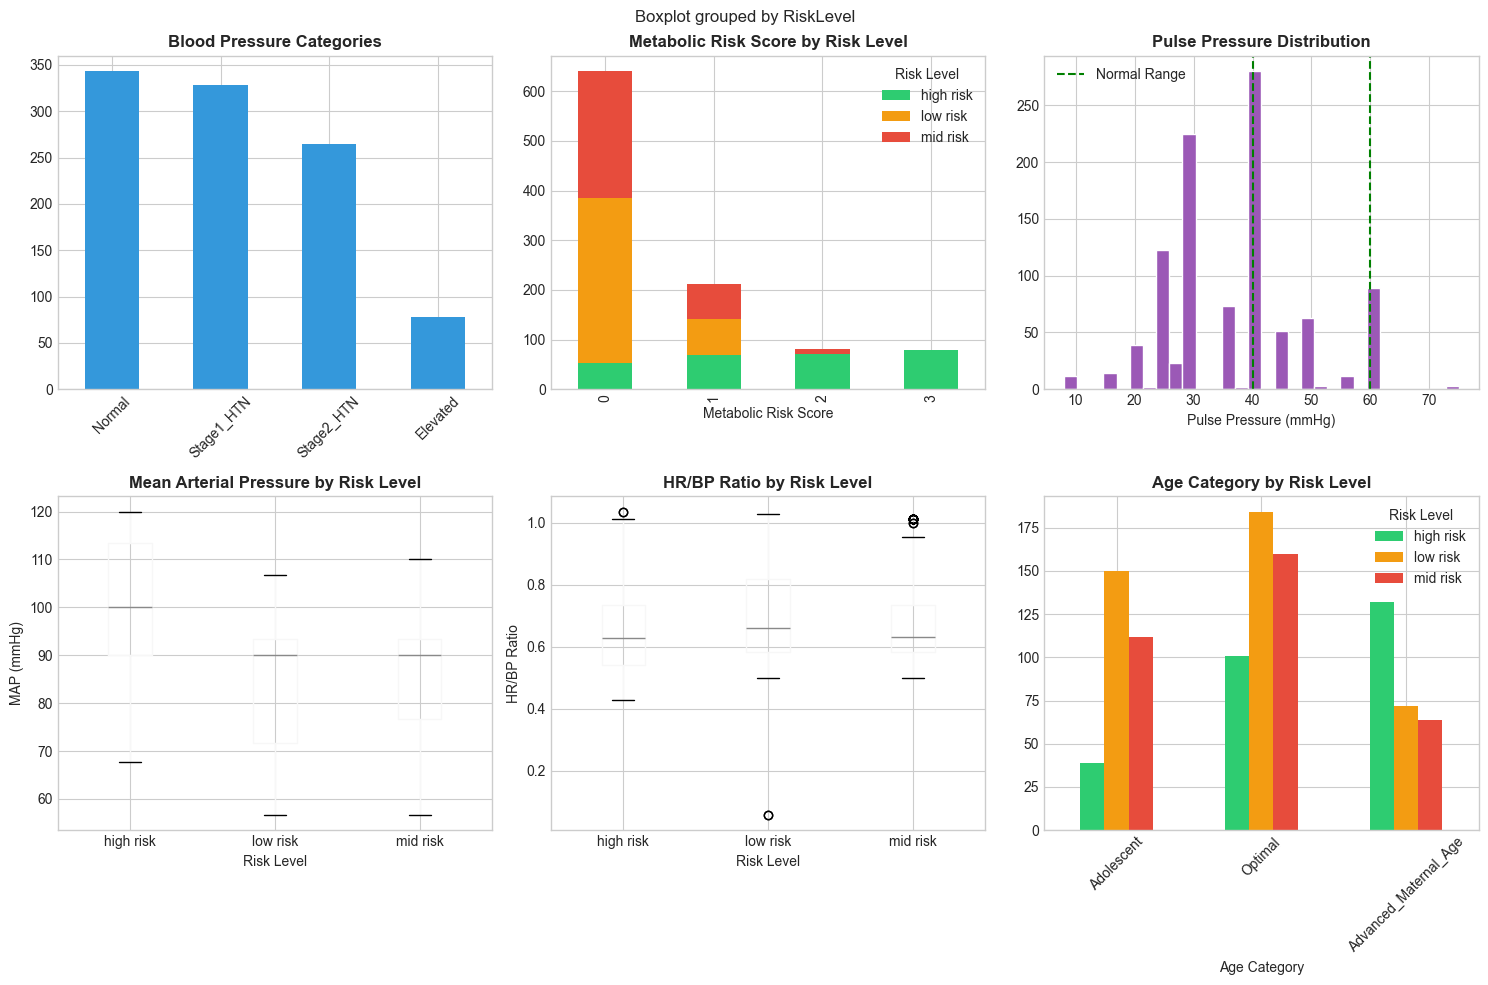


💡 Domain knowledge in action:
   - Pulse Pressure captures arterial stiffness
   - MAP better predicts perfusion than SBP/DBP alone
   - Age categories capture U-shaped maternal risk
   - These features have clinical meaning (not just statistical patterns)


In [29]:
# Visualize created features

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. BP Category distribution
df_features['BP_Category'].value_counts().plot(kind='bar', ax=axes[0,0], color='#3498db')
axes[0,0].set_title('Blood Pressure Categories', fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Metabolic Risk by RiskLevel
pd.crosstab(df_features['Metabolic_Risk'], df_features['RiskLevel']).plot(
    kind='bar', stacked=True, ax=axes[0,1], color=['#2ecc71','#f39c12','#e74c3c'])
axes[0,1].set_title('Metabolic Risk Score by Risk Level', fontweight='bold')
axes[0,1].set_xlabel('Metabolic Risk Score')
axes[0,1].legend(title='Risk Level')

# 3. Pulse Pressure distribution
axes[0,2].hist(df_features['Pulse_Pressure'], bins=30, color='#9b59b6', edgecolor='white')
axes[0,2].axvline(40, color='green', linestyle='--', label='Normal Range')
axes[0,2].axvline(60, color='green', linestyle='--')
axes[0,2].set_title('Pulse Pressure Distribution', fontweight='bold')
axes[0,2].set_xlabel('Pulse Pressure (mmHg)')
axes[0,2].legend()

# 4. MAP by Risk Level
df_features.boxplot(column='MAP', by='RiskLevel', ax=axes[1,0])
axes[1,0].set_title('Mean Arterial Pressure by Risk Level', fontweight='bold')
axes[1,0].set_xlabel('Risk Level')
axes[1,0].set_ylabel('MAP (mmHg)')
plt.sca(axes[1,0])
plt.xticks(rotation=0)

# 5. HR/BP Ratio by Risk Level
df_features.boxplot(column='HR_BP_Ratio', by='RiskLevel', ax=axes[1,1])
axes[1,1].set_title('HR/BP Ratio by Risk Level', fontweight='bold')
axes[1,1].set_xlabel('Risk Level')
axes[1,1].set_ylabel('HR/BP Ratio')
plt.sca(axes[1,1])
plt.xticks(rotation=0)

# 6. Age Category by Risk Level
pd.crosstab(df_features['Age_Category'], df_features['RiskLevel']).plot(
    kind='bar', ax=axes[1,2], color=['#2ecc71','#f39c12','#e74c3c'])
axes[1,2].set_title('Age Category by Risk Level', fontweight='bold')
axes[1,2].set_xlabel('Age Category')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].legend(title='Risk Level')

plt.tight_layout()
plt.show()

print("\n💡 Domain knowledge in action:")
print("   - Pulse Pressure captures arterial stiffness")
print("   - MAP better predicts perfusion than SBP/DBP alone")
print("   - Age categories capture U-shaped maternal risk")
print("   - These features have clinical meaning (not just statistical patterns)")

---
## Section 10 — Feature Selection

### Why Select Features?

After creating features, we often have too many:
- **Curse of dimensionality**: More features = exponentially more data needed
- **Overfitting risk**: Model memorizes noise in irrelevant features
- **Computational cost**: Training time increases
- **Interpretability**: Simpler models are easier to explain

**Goal**: Keep only features that contribute to prediction.

---

### Feature Selection Method 1: Variance Threshold

**Method**: Remove features with near-zero variance.

**Logic**: If a feature has the same value for 95%+ of samples, it carries little information.

**Example**: 
- Feature "Gender" with 99% Female, 1% Male → remove
- Feature "Risk Level" with balanced distribution → keep

**When to use**: Always as first step (computationally cheap, no harm)

---

### Feature Selection Method 2: Correlation-Based

**Method**: Remove highly correlated feature pairs.

**Logic**: If two features have correlation > 0.9, they're redundant. Keep one, drop the other.

**Example**: SystolicBP and MAP are highly correlated (r = 0.95) → keep one

**Threshold**: Typically drop if |correlation| > 0.9

**Caution**: Correlation is linear. May miss non-linear relationships.

---

### Feature Selection Method 3: Univariate Statistical Tests

**Method**: Test each feature's relationship with target independently.

**For classification**:
- ANOVA F-test: Compares feature means across classes
- Chi-square: For categorical features

**For regression**:
- F-test: Linear relationship
- Mutual information: Non-linear relationship

**Pros**: Fast, simple, no model needed  
**Cons**: Ignores feature interactions

---

### Feature Selection Method 4: Recursive Feature Elimination (RFE)

**Method**: 
1. Train model with all features
2. Rank features by importance
3. Remove least important feature
4. Repeat until desired number reached

**Pros**: Considers feature interactions  
**Cons**: Computationally expensive (trains many models)

**When to use**: When accuracy is critical and you have compute time

---


In [30]:
# Feature Selection

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

print("FEATURE SELECTION")
print("="*70)

# Prepare features (encode categorical for selection)
df_select = df_features.copy()

# Encode BP_Category and Age_Category
df_select['BP_Category_Encoded'] = LabelEncoder().fit_transform(df_select['BP_Category'])
df_select['Age_Category_Encoded'] = LabelEncoder().fit_transform(df_select['Age_Category'])
df_select['RiskLevel_Encoded'] = LabelEncoder().fit_transform(df_select['RiskLevel'])

# Select numeric features
feature_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
                'Metabolic_Risk', 'Pulse_Pressure', 'MAP', 'HR_BP_Ratio',
                'BP_Category_Encoded', 'Age_Category_Encoded']

X = df_select[feature_cols]
y = df_select['RiskLevel_Encoded']

print(f"Starting features: {len(feature_cols)}")

# Method 1: Variance Threshold
var_selector = VarianceThreshold(threshold=0.01)
X_var = var_selector.fit_transform(X)
var_kept = [feature_cols[i] for i in range(len(feature_cols)) if var_selector.get_support()[i]]

print(f"\n1. VARIANCE THRESHOLD")
print(f"   Features kept: {len(var_kept)} / {len(feature_cols)}")
print(f"   Removed: {set(feature_cols) - set(var_kept)}")

# Method 2: Correlation
corr_matrix = X[var_kept].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

print(f"\n2. CORRELATION-BASED")
print(f"   High correlation pairs (>0.9): {to_drop}")

corr_kept = [f for f in var_kept if f not in to_drop]
print(f"   Features kept: {len(corr_kept)} / {len(var_kept)}")

# Method 3: ANOVA F-test (SelectKBest)
k_best = SelectKBest(score_func=f_classif, k=8)
k_best.fit(X[corr_kept], y)

scores = pd.DataFrame({
    'Feature': corr_kept,
    'F_Score': k_best.scores_,
    'Selected': k_best.get_support()
}).sort_values('F_Score', ascending=False)

print(f"\n3. ANOVA F-TEST (Top 8)")
print(scores.to_string(index=False))

selected_features = scores[scores['Selected']]['Feature'].tolist()

print(f"\n✅ Final selected features: {selected_features}")

FEATURE SELECTION
Starting features: 12

1. VARIANCE THRESHOLD
   Features kept: 12 / 12
   Removed: set()

2. CORRELATION-BASED
   High correlation pairs (>0.9): ['MAP']
   Features kept: 11 / 12

3. ANOVA F-TEST (Top 8)
             Feature    F_Score  Selected
      Metabolic_Risk 428.514360      True
                  BS 331.158072      True
          SystolicBP  95.902952      True
         DiastolicBP  84.960133      True
 BP_Category_Encoded  54.015883      True
                 Age  46.114005      True
      Pulse_Pressure  32.264876      True
           HeartRate  20.452685      True
         HR_BP_Ratio  19.530726     False
            BodyTemp  16.445847     False
Age_Category_Encoded   2.370891     False

✅ Final selected features: ['Metabolic_Risk', 'BS', 'SystolicBP', 'DiastolicBP', 'BP_Category_Encoded', 'Age', 'Pulse_Pressure', 'HeartRate']


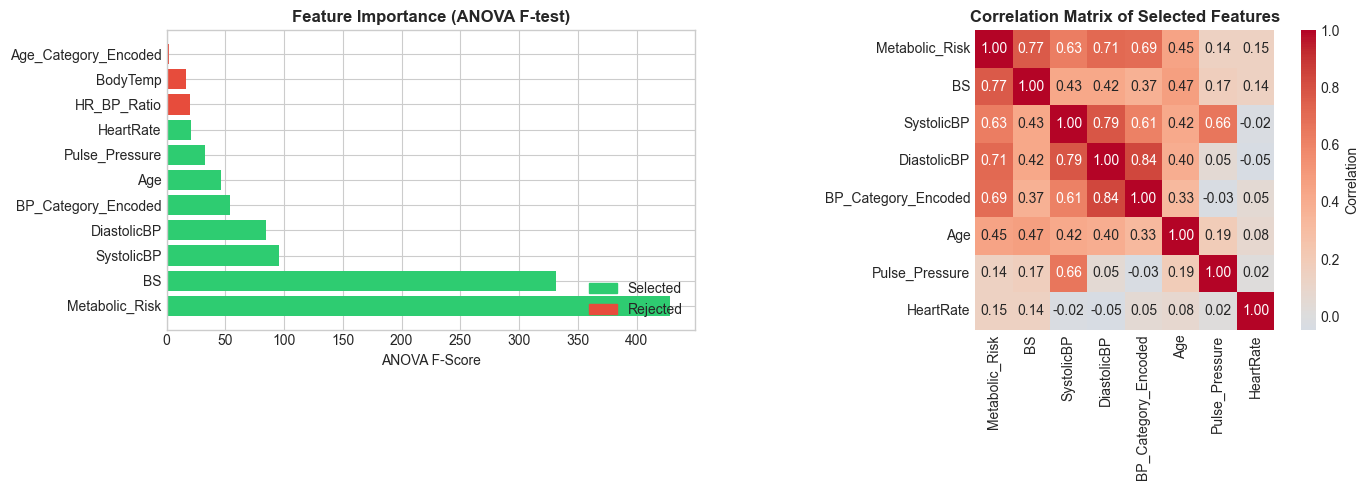


💡 Feature selection reduces:
   12 → 8 features
   Keeps most informative features
   Reduces overfitting risk


In [31]:
# Visualize feature selection results

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F-scores bar chart
colors = ['#2ecc71' if sel else '#e74c3c' for sel in scores['Selected']]
ax1.barh(scores['Feature'], scores['F_Score'], color=colors)
ax1.set_xlabel('ANOVA F-Score')
ax1.set_title('Feature Importance (ANOVA F-test)', fontweight='bold')
ax1.legend([plt.Rectangle((0,0),1,1, color='#2ecc71'), 
            plt.Rectangle((0,0),1,1, color='#e74c3c')],
           ['Selected', 'Rejected'], loc='lower right')

# Correlation heatmap of selected features
selected_corr = X[selected_features].corr()
sns.heatmap(selected_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax2, cbar_kws={'label': 'Correlation'})
ax2.set_title('Correlation Matrix of Selected Features', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Feature selection reduces:")
print(f"   {len(feature_cols)} → {len(selected_features)} features")
print(f"   Keeps most informative features")
print(f"   Reduces overfitting risk")

---
# Part 3: EMR Data Types & Clinical Standards

Understanding healthcare data standards is essential for working with real EHR data.

---

## Section 11 — Clinical Coding Systems

Healthcare uses standardized coding systems to ensure interoperability and billing accuracy.

---

### ICD-10-CM (International Classification of Diseases)

**Purpose**: Diagnosis coding for billing and epidemiology

**Structure**: Alphanumeric codes, 3-7 characters
- First character: Letter (category)
- Next 2 characters: Numbers (subcategory)
- After decimal: Specificity

**Examples**:
- **E11.9**: Type 2 diabetes mellitus without complications
  - E11: Type 2 diabetes
  - .9: Without complications
- **I10**: Essential (primary) hypertension
- **J45.901**: Unspecified asthma with acute exacerbation

**Hierarchical Structure**:
```
E00-E89: Endocrine, nutritional, metabolic diseases
  E08-E13: Diabetes mellitus
    E11: Type 2 diabetes
      E11.9: Without complications
      E11.65: With hyperglycemia
```

**ML Challenge**: **High cardinality** — 70,000+ codes  
**Solution**: Group into clinical categories using:
- **Elixhauser Comorbidity Index**: Maps ICD → 31 comorbidity groups
- **CCS (Clinical Classifications Software)**: Maps ICD → 285 categories
- **Disease chapters**: Use first 3 characters (E11.* → all diabetes)

---

### CPT (Current Procedural Terminology)

**Purpose**: Procedure coding for billing

**Structure**: 5-digit numeric codes

**Examples**:
- **99213**: Office visit, established patient, moderate complexity
- **93000**: Electrocardiogram (ECG)
- **71046**: Chest X-ray, 2 views

**Categories**:
- 00100-01999: Anesthesia
- 10000-69990: Surgery
- 70000-79999: Radiology
- 80000-89999: Laboratory
- 90000-99999: Evaluation & Management

**ML Use**: Procedure patterns predict:
- Patient complexity (many procedures → sicker)
- Care utilization
- Cost forecasting

---

### LOINC (Logical Observation Identifiers Names and Codes)

**Purpose**: Lab results and clinical observations

**Structure**: Numeric codes + components

**Examples**:
- **2160-0**: Creatinine [Mass/volume] in Serum or Plasma
- **2345-7**: Glucose [Mass/volume] in Serum or Plasma
- **4548-4**: Hemoglobin A1c/Hemoglobin.total in Blood

**Components** (6-part naming):
1. Component: What's measured (Glucose)
2. Property: Type of measure (Mass/volume)
3. Timing: When measured (Random, Fasting)
4. System: Sample type (Serum, Plasma)
5. Scale: Quantitative vs Qualitative
6. Method: How measured (if relevant)

**ML Challenge**: Long-format data (one row per test result)  
**Solution**: **Pivot to wide format** — one row per patient, one column per test

**Example transformation**:
```
Long format:
patient_id | LOINC | value
PT001      | 2160-0| 1.2
PT001      | 2345-7| 95
PT002      | 2160-0| 0.8

Wide format:
patient_id | Creatinine | Glucose
PT001      | 1.2        | 95
PT002      | 0.8        | NaN
```

---

### RxNorm (Medications)

**Purpose**: Normalized drug naming

**Structure**: Concept unique identifiers (RxCUI)

**Example**:
- **313782**: Metformin 500 MG Oral Tablet
  - Generic name: Metformin
  - Strength: 500 MG
  - Dose form: Oral Tablet

**Why needed**: Same drug has many names:
- Brand: Glucophage
- Generic: Metformin
- With strength: Metformin 500mg
- With form: Metformin 500mg tablet

RxNorm maps all → single concept.

**ML Use**: 
- Medication counts (polypharmacy)
- Drug class grouping (all beta blockers)
- Drug-drug interaction detection

---

### SNOMED CT (Clinical Concepts)

**Purpose**: Comprehensive clinical terminology

**Structure**: Hierarchical ontology with 350,000+ concepts

**Example**:
- **73211009**: Diabetes mellitus (disorder)
  - Is-a: Endocrine disorder
  - Finding site: Pancreas
  - Associated with: Hyperglycemia

**Use**: Clinical decision support, semantic interoperability

**ML Note**: Too granular for most tasks. Usually map to ICD-10 or custom groupings.

---

### Why These Standards Matter for ML

1. **Data Integration**: Combine data from multiple hospitals
2. **Feature Engineering**: Code groupings become features
3. **Transfer Learning**: Models trained on coded data generalize better
4. **Interpretability**: "E11.9" is more meaningful than "diagnosis_42"
5. **Compliance**: Required for billing and regulatory reporting

**Key Principle**: Learn the standards — they define the data model.

Without understanding ICD/CPT/LOINC, healthcare datasets are just numbers. With understanding, they become clinical narratives.

---


---
## Section 12 — FHIR (Fast Healthcare Interoperability Resources)

### What is FHIR?

**FHIR** (pronounced "fire") is the modern standard for exchanging healthcare data electronically.

**Developed by**: HL7 (Health Level 7) International  
**Current version**: R4 (Release 4)  
**Format**: JSON or XML  
**Architecture**: RESTful API

---

### Why FHIR Matters

**Old way** (HL7 v2, v3):
- Complex, rigid message formats
- Difficult to parse
- Poor interoperability

**FHIR way**:
- Human-readable JSON
- RESTful API (familiar to developers)
- Modular "resources"
- Web-based

**Real-world adoption**:
- Epic (largest EHR vendor): FHIR API
- Cerner: FHIR API
- Apple Health: Uses FHIR
- CMS (Medicare): Requires FHIR for data sharing

---

### FHIR Resource Structure

**Resource**: A discrete piece of healthcare data.

**Common resources**:
- **Patient**: Demographics
- **Condition**: Diagnoses
- **Observation**: Lab results, vitals
- **MedicationRequest**: Prescriptions
- **Procedure**: Surgical/diagnostic procedures
- **Encounter**: Hospital visits

**Example — Condition Resource (JSON)**:
```json
{
  "resourceType": "Condition",
  "id": "f201",
  "clinicalStatus": {
    "coding": [{"code": "active"}]
  },
  "code": {
    "coding": [{
      "system": "http://hl7.org/fhir/sid/icd-10",
      "code": "E11.9",
      "display": "Type 2 diabetes mellitus without complications"
    }]
  },
  "subject": {
    "reference": "Patient/f001"
  },
  "onsetDateTime": "2019-03-15"
}
```

---

### Parsing FHIR Data for ML

**Challenge**: Nested JSON structure → need flat DataFrame

**Strategy**:
1. Load JSON bundle
2. Extract relevant resources
3. Parse nested fields
4. Convert to DataFrame
5. Merge with other data sources

**Example workflow**:
```python
# Load FHIR bundle
bundle = json.load(open('patient_conditions.json'))

# Extract Condition resources
conditions = []
for entry in bundle['entry']:
    if entry['resource']['resourceType'] == 'Condition':
        resource = entry['resource']
        conditions.append({
            'patient_id': resource['subject']['reference'].split('/')[-1],
            'icd10_code': resource['code']['coding'][0]['code'],
            'diagnosis': resource['code']['coding'][0]['display'],
            'onset_date': resource.get('onsetDateTime'),
            'status': resource['clinicalStatus']['coding'][0]['code']
        })

df_conditions = pd.DataFrame(conditions)
```

---

### ML Applications with FHIR Data

1. **Comorbidity extraction**: Parse Condition resources → count of diagnoses
2. **Medication patterns**: MedicationRequest → polypharmacy indicator
3. **Temporal analysis**: onsetDateTime → disease progression timeline
4. **Lab trends**: Observation resources → glucose trajectory over time
5. **Care gaps**: Missing resources → adherence flags

---


In [32]:
# FHIR Parsing Demonstration

import json

# Sample FHIR R4 Bundle (simulated)
fhir_bundle = {
  "resourceType": "Bundle",
  "type": "searchset",
  "entry": [
    {
      "resource": {
        "resourceType": "Condition",
        "id": "cond-001",
        "subject": {"reference": "Patient/PT001"},
        "code": {
          "coding": [{
            "system": "http://hl7.org/fhir/sid/icd-10",
            "code": "E11.9",
            "display": "Type 2 diabetes mellitus without complications"
          }]
        },
        "clinicalStatus": {"coding": [{"code": "active"}]},
        "onsetDateTime": "2019-03-15"
      }
    },
    {
      "resource": {
        "resourceType": "Condition",
        "id": "cond-002",
        "subject": {"reference": "Patient/PT001"},
        "code": {
          "coding": [{
            "system": "http://hl7.org/fhir/sid/icd-10",
            "code": "I10",
            "display": "Essential (primary) hypertension"
          }]
        },
        "clinicalStatus": {"coding": [{"code": "active"}]},
        "onsetDateTime": "2020-07-01"
      }
    },
    {
      "resource": {
        "resourceType": "Observation",
        "id": "obs-001",
        "subject": {"reference": "Patient/PT001"},
        "code": {
          "coding": [{
            "system": "http://loinc.org",
            "code": "4548-4",
            "display": "Hemoglobin A1c/Hemoglobin.total in Blood"
          }]
        },
        "valueQuantity": {"value": 9.2, "unit": "%"},
        "effectiveDateTime": "2024-01-15"
      }
    }
  ]
}

print("FHIR R4 BUNDLE PARSING")
print("="*70)
print(f"Bundle contains {len(fhir_bundle['entry'])} resources")

# Parse Conditions
conditions = []
for entry in fhir_bundle['entry']:
    resource = entry['resource']
    if resource['resourceType'] == 'Condition':
        coding = resource['code']['coding'][0]
        conditions.append({
            'patient_id': resource['subject']['reference'].split('/')[-1],
            'icd10_code': coding['code'],
            'diagnosis': coding['display'],
            'onset_date': resource.get('onsetDateTime'),
            'status': resource['clinicalStatus']['coding'][0]['code']
        })

df_conditions = pd.DataFrame(conditions)
print(f"\nParsed {len(df_conditions)} Condition resources:")
print(df_conditions.to_string(index=False))

# Parse Observations (Lab Results)
observations = []
for entry in fhir_bundle['entry']:
    resource = entry['resource']
    if resource['resourceType'] == 'Observation':
        coding = resource['code']['coding'][0]
        value_qty = resource.get('valueQuantity', {})
        observations.append({
            'patient_id': resource['subject']['reference'].split('/')[-1],
            'loinc_code': coding['code'],
            'test_name': coding['display'],
            'value': value_qty.get('value'),
            'unit': value_qty.get('unit'),
            'date': resource.get('effectiveDateTime')
        })

df_observations = pd.DataFrame(observations)
print(f"\nParsed {len(df_observations)} Observation resources:")
print(df_observations.to_string(index=False))

print(f"\n✅ FHIR → DataFrame conversion complete")
print(f"   Ready for ML feature engineering")

FHIR R4 BUNDLE PARSING
Bundle contains 3 resources

Parsed 2 Condition resources:
patient_id icd10_code                                      diagnosis onset_date status
     PT001      E11.9 Type 2 diabetes mellitus without complications 2019-03-15 active
     PT001        I10               Essential (primary) hypertension 2020-07-01 active

Parsed 1 Observation resources:
patient_id loinc_code                                test_name  value unit       date
     PT001     4548-4 Hemoglobin A1c/Hemoglobin.total in Blood    9.2    % 2024-01-15

✅ FHIR → DataFrame conversion complete
   Ready for ML feature engineering


---
## Section 13 — Clinical NLP: Extracting Features from Notes

### Why Clinical Notes Matter

**Structured EHR fields** capture:
- Diagnoses (ICD codes)
- Procedures (CPT codes)
- Lab results (LOINC)
- Medications (RxNorm)

**Clinical notes** contain information NOT in structured fields:
- Physician reasoning: "probable pneumonia vs COPD exacerbation"
- Patient history: "patient reports chest pain for 3 days"
- Social determinants: "homeless, limited access to medications"
- Symptom details: "sharp, stabbing pain, worse with deep breath"
- Temporal context: "symptoms started yesterday evening"

**Statistic**: ~80% of clinical information is in free text notes.

**Problem**: Free text is unstructured. Can't use directly in ML models.

**Solution**: **Named Entity Recognition (NER)** extracts structured entities from text.

---

### Named Entity Recognition (NER)

**Definition**: Automatically identify and classify named entities in text.

**Medical entities**:
- **Conditions**: "hypertension", "diabetes", "COPD"
- **Medications**: "Metformin 500mg", "Lisinopril"
- **Procedures**: "appendectomy", "CT scan"
- **Lab values**: "HbA1c 9.2%", "BP 148/92"
- **Anatomy**: "left ventricle", "anterior wall"
- **Temporal**: "yesterday", "for 3 days"

---

### NER Approaches

**1. Rule-Based NER** (Simple but effective):
- Define patterns using regular expressions
- Match against medical dictionaries
- Fast, no training needed
- Good for well-defined entities

**Example patterns**:
```python
MEDICATION = r'(Metformin|Lisinopril|Atorvastatin)'
LAB_VALUE = r'HbA1c\s+[\d.]+%'
BP_VALUE = r'BP\s+\d+/\d+\s?mmHg'
```

**2. ML-Based NER** (More accurate, requires training):
- **CRF (Conditional Random Fields)**: Classical ML
- **BiLSTM-CRF**: Deep learning
- **BERT-based**: Transformers (state-of-art)
  - Clinical BERT
  - BioBERT
  - PubMedBERT

**3. Pre-trained Medical NER**:
- **scispaCy**: Medical NER models
- **MedSpaCy**: Clinical NER extensions
- **Stanza**: Biomedical models

---

### Converting NER Output to ML Features

After extracting entities, create features:

**1. Count features**:
- `n_conditions_mentioned` = number of conditions in note
- `n_medications` = number of drugs listed
- `n_abnormal_labs` = lab values outside normal range

**2. Binary flags**:
- `has_diabetes` = 1 if diabetes mentioned, 0 otherwise
- `has_cardiac_symptoms` = 1 if chest pain / SOB mentioned
- `on_anticoagulant` = 1 if warfarin / heparin mentioned

**3. Severity indicators**:
- `symptom_severity` = count of words like "severe", "acute", "chronic"
- `pain_intensity` = extract numeric pain scale (0-10)

**4. Temporal features**:
- `symptom_duration_days` = extract "for 3 days" → 3
- `is_acute_onset` = 1 if "sudden", "acute" mentioned

---

### Example Workflow

```python
# 1. Run NER on clinical note
entities = ner_model.extract(clinical_note)

# 2. Convert to features
features = {
    'n_conditions': len([e for e in entities if e.type == 'CONDITION']),
    'n_medications': len([e for e in entities if e.type == 'MEDICATION']),
    'has_diabetes': 'diabetes' in [e.text.lower() for e in entities],
    'has_pain': any('pain' in e.text.lower() for e in entities)
}
```

---


In [33]:
# Clinical NLP: Rule-Based NER Demo

import re

# Sample clinical notes
notes = [
    ("PT001", 
     "Patient is a 65-year-old male with uncontrolled Type 2 diabetes (HbA1c 9.2%) "
     "and essential hypertension. Started on Metformin 500mg BID and Lisinopril 10mg daily. "
     "Blood pressure 148/92 mmHg. Follow-up in 2 weeks."),
    
    ("PT002",
     "62-year-old female presenting with acute exacerbation of asthma. SpO2 88% on room air. "
     "Prescribed Albuterol MDI 2 puffs Q4H and Prednisone 40mg PO daily for 5 days. "
     "Peak flow 210 L/min."),
    
    ("PT003",
     "Follow-up for chronic kidney disease Stage 3 (eGFR 42 mL/min). Creatinine 1.8 mg/dL. "
     "Continue Losartan 50mg daily. Referred to nephrology for further management.")
]

# Define NER patterns
NER_PATTERNS = {
    'CONDITION': [
        r'Type 2 diabetes', r'diabetes', r'hypertension',
        r'asthma', r'CKD', r'chronic kidney disease'
    ],
    'MEDICATION': [
        r'Metformin', r'Lisinopril', r'Albuterol',
        r'Prednisone', r'Losartan'
    ],
    'LAB_VALUE': [
        r'HbA1c\s+[\d.]+%',
        r'(?:BP|Blood pressure)\s+\d+/\d+\s?mmHg',
        r'SpO2\s+\d+%',
        r'eGFR\s+[\d.]+\s?mL/min',
        r'Creatinine\s+[\d.]+\s?mg/dL',
        r'Peak flow\s+\d+\s?L/min'
    ],
    'MEDICATION_DOSE': [
        r'\d+\s?mg', r'\d+\s?puffs'
    ]
}

def extract_entities(text):
    """Extract named entities using regex patterns"""
    results = []
    for entity_type, patterns in NER_PATTERNS.items():
        for pattern in patterns:
            for match in re.finditer(pattern, text, flags=re.IGNORECASE):
                results.append({
                    'entity_type': entity_type,
                    'text': match.group(),
                    'start': match.start(),
                    'end': match.end()
                })
    return sorted(results, key=lambda x: x['start'])

print("CLINICAL NER EXTRACTION")
print("="*70)

# Extract entities from each note
for patient_id, note in notes:
    print(f"\n{'─'*70}")
    print(f"Patient: {patient_id}")
    print(f"Note: {note[:100]}...")
    print(f"\nExtracted Entities:")
    
    entities = extract_entities(note)
    for ent in entities:
        print(f"  [{ent['entity_type']:20s}] {ent['text']}")

print(f"\n{'='*70}")

CLINICAL NER EXTRACTION

──────────────────────────────────────────────────────────────────────
Patient: PT001
Note: Patient is a 65-year-old male with uncontrolled Type 2 diabetes (HbA1c 9.2%) and essential hypertens...

Extracted Entities:
  [LAB_VALUE           ] HbA1c 9.2%
  [MEDICATION_DOSE     ] 500mg
  [MEDICATION_DOSE     ] 10mg
  [LAB_VALUE           ] Blood pressure 148/92 mmHg

──────────────────────────────────────────────────────────────────────
Patient: PT002
Note: 62-year-old female presenting with acute exacerbation of asthma. SpO2 88% on room air. Prescribed Al...

Extracted Entities:
  [LAB_VALUE           ] SpO2 88%
  [MEDICATION_DOSE     ] 2 puffs
  [MEDICATION_DOSE     ] 40mg
  [LAB_VALUE           ] Peak flow 210 L/min

──────────────────────────────────────────────────────────────────────
Patient: PT003
Note: Follow-up for chronic kidney disease Stage 3 (eGFR 42 mL/min). Creatinine 1.8 mg/dL. Continue Losart...

Extracted Entities:
  [LAB_VALUE           ] eGFR 4

In [34]:
# Convert NER output to ML features

def note_to_features(note_text):
    """Convert clinical note to ML features using NER"""
    entities = extract_entities(note_text)
    
    conditions = [e['text'].lower() for e in entities if e['entity_type'] == 'CONDITION']
    medications = [e['text'] for e in entities if e['entity_type'] == 'MEDICATION']
    lab_values = [e['text'] for e in entities if e['entity_type'] == 'LAB_VALUE']
    
    return {
        'note_length': len(note_text),
        'n_conditions': len(conditions),
        'n_medications': len(medications),
        'n_lab_values': len(lab_values),
        'has_diabetes': int(any('diabetes' in c for c in conditions)),
        'has_hypertension': int(any('hypertension' in c for c in conditions)),
        'has_asthma': int(any('asthma' in c for c in conditions)),
        'has_ckd': int(any('kidney' in c or 'ckd' in c for c in conditions)),
        'on_metformin': int(any('metformin' in m.lower() for m in medications)),
        'on_beta_blocker': int(any('lol' in m.lower() for m in medications)),  # -lol suffix
    }

# Convert notes to feature DataFrame
note_features = []
for patient_id, note in notes:
    features = note_to_features(note)
    features['patient_id'] = patient_id
    note_features.append(features)

df_note_features = pd.DataFrame(note_features)

print("NLP-DERIVED FEATURES FROM CLINICAL NOTES")
print("="*70)
print(df_note_features.to_string(index=False))

print(f"\n💡 Clinical notes → structured features")
print(f"   Can now use in ML models alongside structured data")
print(f"   Captures information not in ICD codes or lab values")

NLP-DERIVED FEATURES FROM CLINICAL NOTES
 note_length  n_conditions  n_medications  n_lab_values  has_diabetes  has_hypertension  has_asthma  has_ckd  on_metformin  on_beta_blocker patient_id
         212             0              0             2             0                 0           0        0             0                0      PT001
         185             0              0             2             0                 0           0        0             0                0      PT002
         161             0              0             2             0                 0           0        0             0                0      PT003

💡 Clinical notes → structured features
   Can now use in ML models alongside structured data
   Captures information not in ICD codes or lab values


---
## 🎯 Complete Summary

### What We Covered

**Part 1: Data Cleaning**
- Missing data types (MCAR, MAR, MNAR) and appropriate strategies
- Outlier detection (Z-score, IQR, Isolation Forest) and treatment
- Duplicates and string normalization
- Date parsing and type conversions

**Part 2: Feature Engineering**
- Categorical encoding (One-Hot, Label, Target, Frequency)
- Feature scaling (Standard, MinMax, Robust) with train-only fitting
- **Feature creation using domain knowledge**
- Feature selection (Variance, Correlation, ANOVA, RFE)

**Part 3: EMR Standards**
- **ICD-10-CM**: Diagnosis codes and hierarchical grouping
- **CPT**: Procedure codes for billing
- **LOINC**: Lab results standardization
- **RxNorm**: Medication naming
- **FHIR**: Modern data exchange standard
- **Clinical NLP**: Extracting features from free-text notes

---

### Key Principles

1. **Domain knowledge > automated methods** for feature creation
2. **Understand missingness type** before choosing imputation
3. **Fit preprocessing on train only** to prevent data leakage
4. **Preserve patient records** when possible (clip vs delete)
5. **Learn clinical standards** — they define the data model
6. **Extract features from notes** — 80% of clinical info is text

---

### Real-World Application

These techniques form the foundation of clinical ML systems:
- **Readmission prediction**: Uses all of these methods
- **Risk stratification**: Relies on proper feature engineering
- **Clinical decision support**: Requires understanding of standards
- **Population health**: Needs proper data quality

---

**Dataset Locations**:
- Healthcare: `../data/healthcare_dataset.csv`
- Maternal Health: `../data/Maternal_Health_Risk_Data_Set.csv`

**Next Steps**: Apply these techniques to your own healthcare datasets!
